# Hedging the Unhedgeable
### Immunizing a book of callable EM bonds with vanilla swaps (and measuring, in VaR, how far that gets you)

I recently became interested in a very specific corner of fixed income: optionality hedging, and the instrument valuation that comes with it. A bond desk can end up holding bonds with embedded call options - in my experience mostly Bermudan-style structures. At first glance we might think hedging them is easy: just enter the offsetting position with the same calendar and the same price structure. But the moment you leave the world of AAA issuers and move into EM, or more broadly anything below A+, you have **two stochastic factors** driving the call decision: interest rates *and* the issuer's credit spread.

The setup for this project: a AAA-rated institution funds itself at SOFR flat and invests in EM callable bonds. The credit risk is deliberate. It is the insitution's mandate, that is how they earn the spread. What they want to strip out is the pure interest-rate duration risk, using nothing more exotic than vanilla interest rate swaps.

The intuition that started the project fits in two lines: *if you have two stochastic factors, and an option whose value depends on both, you generally cannot hedge it with an instrument that sees only one of them.* Taken literally that sounds like a dead end for anyone holding callable EM paper. It is not. Because the practical answer is not to hedge each bond's option, but to **immunize the book's rate risk bucket by bucket, on a DV01 basis, with a strip of plain vanilla swaps** — and then to rebalance, because the immunization decays, but we'll get to that later.

So the question this notebook builds toward is deliberately a *portfolio* question:

> **Can you strip the interest-rate risk out of a book of callable EM bonds using vanilla swaps ? How do you size the trade, how much risk does it actually remove, and how fast does it stop working?**

# OUTLINE

## Part I: The Toolkit

1. Bootstrapping the SOFR discount curve  
2. The IRS pricer  
3. A bond pricer with real calendar dates  
4. The key-rate duration engine  
5. Let's introduce optionality: the binomial tree  
6. OAS: the number the desk actually quotes  

Build the pricing and risk machinery from scratch, then validate the callable-bond model against Fabozzi.

---

## Part II: One Bond, Understood Properly

7. Effective duration, and validating it against the book  
8. The KRD fingerprint: bullet vs callable  
9. Three hedges  

Understand where a callable carries its rate risk, then build and compare three ways to hedge it.

---

## Part III: Immunizing the Book

10. DV01 immunization at book level  
11. What this model cannot see: limitations  

Aggregate four EM callables into one KRD vector, hedge the book with swaps, and measure what remains with VaR.

---

Built with `numpy`, `pandas`, `scipy`, and `matplotlib`. No QuantLib.

---
## Part I : The Toolkit

### 1. Bootstrapping the SOFR discount curve

An IRS is a contract where two parties exchange cash flows: one pays a fixed rate on a notional, the other pays a floating rate — for USD, SOFR. Since the death of LIBOR the standard USD SOFR swap is *the* rate hedging instrument. In the LIBOR era a single curve both projected forwards and discounted cash flows; post-crisis this became a multi-curve framework — but for a USD SOFR IRS it effectively collapses back to a single curve: SOFR OIS for both projection and discounting.

I do not have a discount curve readily available, so we construct one from market instrument quotes. The data below is illustrative but realistically shaped — swapping in live quotes is trivial.

**What this curve is, and is not.** What follows is a *simplified* par/discount curve, built to be sufficient for studying hedge mechanics — not a reproduction of a production USD SOFR swaps curve. I use annual periods, act/act-style year fractions and clean maturity dates throughout. A desk curve would carry actual payment frequencies, proper day-count conventions per leg, settlement and holiday-calendar adjustments, real maturity dates, and OIS compounding conventions, with more careful separation of forward projection from discounting. Those details will probably not move the conclusions of this project, which are driven by the shape of a callable’s rate sensitivity and how that shape drifts with credit. I have therefore spent the complexity budget on the lattice, while flagging the curve simplifications here rather than implying more precision than I built.

We have two types of instruments. **OIS (out to 6M)** are single-payment instruments — pay fixed vs overnight-compounded SOFR, settled at maturity — so the discount factor falls straight out of the quote:

$$D = \frac{1}{1 + r \cdot t}$$

In [9]:
import pandas as pd
import numpy as np
import math
from scipy.optimize import brentq
from dateutil.relativedelta import relativedelta
from datetime import date
import matplotlib.pyplot as plt

# market quotes: OIS out to 6M, par swap rates from 1Y to 30Y
market_data = "/Users/medalight/Desktop/Optionality Hedging/Market_Data.xlsx"
df = pd.read_excel(market_data)
df["discount_factor"] = np.nan

# OIS rows (0-5): single payment, so D = 1 / (1 + r * t)
for i in range(0, 6):
    rate  = df.loc[i, "Rate (%)"] / 100
    years = df.loc[i, "Years"]
    df.loc[i, "discount_factor"] = 1 / (1 + rate * years)

print(df[["Tenor", "Years", "Rate (%)", "discount_factor"]].head(6).to_string())

  Tenor    Years  Rate (%)  discount_factor
0    1D  0.00274      3.50         0.999904
1    1W  0.01918      3.52         0.999325
2    1M  0.08493      3.55         0.996994
3    2M  0.16438      3.58         0.994150
4    3M  0.24932      3.62         0.991055
5    6M  0.49863      3.70         0.981885


For swaps, however, the quote is not a zero rate. A swap pays multiple cash flows at different dates, so we cannot isolate a single discount factor directly. Instead we **bootstrap**: solve for one unknown discount factor at a time, shortest maturity outward.

Assume annual fixed coupons, notional 1, priced at par (NPV = 0 at inception). The fixed leg pays $R$ every year; the floating leg is worth $1 - D(n)$. Setting them equal and rearranging for the last unknown discount factor:

$$D(n) = \frac{1 - R \sum_{i=1}^{n-1} D(i)}{1 + R}$$

First problem of the day: we have consecutive annual quotes only out to 5Y. The 7Y swap needs $D(6)$, which is not in the data. The standard fix is **log-linear interpolation** on the discount factors — we assume DFs decay smoothly and exponentially, so we interpolate on the logarithm rather than the raw value. So `get_df` either looks a year up directly, or interpolates it from the two nearest known points.

In [11]:
def get_df(target_year, df_curve):
    # case 1: the year exists in the curve — just look it up
    matching_row = df_curve[df_curve["Years"] == target_year]
    if len(matching_row) > 0 and not np.isnan(matching_row["discount_factor"].values[0]):
        return matching_row["discount_factor"].values[0]

    # case 2: interpolate log-linearly between the two nearest known years
    known = df_curve.dropna(subset=["discount_factor"])
    below = known[known["Years"] < target_year]
    above = known[known["Years"] > target_year]
    if len(below) == 0 or len(above) == 0:
        return np.nan          # nothing to interpolate from (yet)

    t1  = below["Years"].values[-1]
    df1 = below["discount_factor"].values[-1]
    t2  = above["Years"].values[0]
    df2 = above["discount_factor"].values[0]

    w = (target_year - t1) / (t2 - t1)
    return df1 ** (1 - w) * df2 ** w

There is a small bootstrap problem here. To interpolate a missing discount factor such as D(6), I need the surrounding bootstrapped points. But on the first pass, the next point D(7) has not been solved yet. The interpolated and bootstrapped discount factors therefore depend on each other.

A fixed number of passes is not enough. Instead, I repeat the bootstrap and interpolation until the discount factors stop changing. In practice, the fixed-point iteration converges in only a few sweeps.

In [13]:
# pass 1: bootstrap what we can, skipping years we cannot interpolate yet
for i in range(6, len(df)):
    rate  = df.loc[i, "Rate (%)"] / 100
    years = df.loc[i, "Years"]
    coupon_years = list(range(1, int(years)))

    prior_dfs = 0.0
    for cy in coupon_years:
        d = get_df(cy, df)
        if not np.isnan(d):
            prior_dfs += d

    df.loc[i, "discount_factor"] = (1 - rate * prior_dfs) / (1 + rate)

# passes 2..n: now every year is interpolatable — sweep until stable
for sweep in range(20):
    max_change = 0.0
    for i in range(6, len(df)):
        rate  = df.loc[i, "Rate (%)"] / 100
        years = df.loc[i, "Years"]

        prior_dfs = 0.0
        for cy in range(1, int(years)):
            prior_dfs += get_df(cy, df)

        new_df = (1 - rate * prior_dfs) / (1 + rate)
        max_change = max(max_change, abs(new_df - df.loc[i, "discount_factor"]))
        df.loc[i, "discount_factor"] = new_df

    if max_change < 1e-10:            # nothing moved — we are done
        break

print(f"converged after {sweep + 1} sweeps")
print(df[["Tenor", "Years", "Rate (%)", "discount_factor"]].to_string())

converged after 16 sweeps
   Tenor     Years  Rate (%)  discount_factor
0     1D   0.00274      3.50         0.999904
1     1W   0.01918      3.52         0.999325
2     1M   0.08493      3.55         0.996994
3     2M   0.16438      3.58         0.994150
4     3M   0.24932      3.62         0.991055
5     6M   0.49863      3.70         0.981885
6     1Y   1.00000      3.75         0.963855
7     2Y   2.00000      3.85         0.927195
8     3Y   3.00000      3.98         0.889340
9     4Y   4.00000      4.10         0.851109
10    5Y   5.00000      4.20         0.813318
11    7Y   7.00000      4.35         0.740669
12   10Y  10.00000      4.50         0.640863
13   15Y  15.00000      4.60         0.504850
14   20Y  20.00000      4.65         0.397537
15   30Y  30.00000      4.70         0.246152


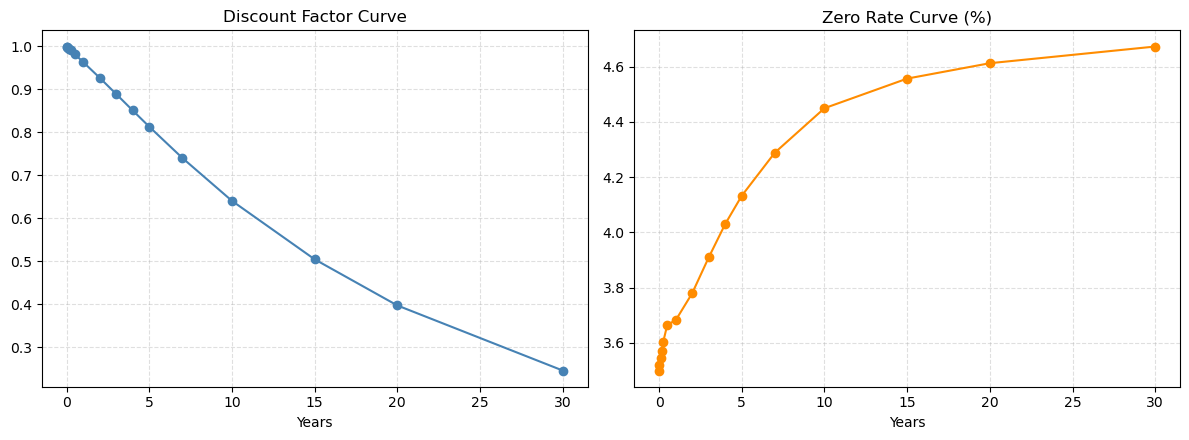

In [14]:
# visual sanity check: DFs decay smoothly, zero curve is sensibly shaped
plot_years = df[df["Years"] > 0]["Years"].values
plot_dfs   = df[df["Years"] > 0]["discount_factor"].values

plot_rates = []
for d, t in zip(plot_dfs, plot_years):
    plot_rates.append(-np.log(d) / t * 100)     # continuously compounded zero

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(plot_years, plot_dfs, color="steelblue", marker="o")
ax1.set_title("Discount Factor Curve")
ax1.set_xlabel("Years")
ax1.grid(True, linestyle="--", alpha=0.4)

ax2.plot(plot_years, plot_rates, color="darkorange", marker="o")
ax2.set_title("Zero Rate Curve (%)")
ax2.set_xlabel("Years")
ax2.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### 2. The IRS pricer

Worth pausing on *why* we did this. By bootstrapping we have not reproduced information we already had. We have converted a sparse set of market quotes into a continuous pricing tool that can value **any** cash flow at **any** future date: instruments not quoted on the curve, forward-starting swaps, off-market swaps, and the risk on all of them.

The pricer below identifies the annual coupon dates, pulls a discount factor for each from the curve, and computes: the **annuity** (PV of 1bp paid on every coupon date), the **par rate** (the fixed rate making the swap worth zero), the **fixed rate** matching any target NPV, and the **DV01**.

In [18]:
def price_swap(df_curve, tenor, notional, start_year=0, npv=0, verbose=True):
    # make sure year 0 exists on the curve with DF = 1
    df_temp = df_curve
    if 0.0 not in df_temp["Years"].values:
        row_0 = {"Tenor": "0Y", "Years": 0.0, "Rate (%)": 0.0, "discount_factor": 1.0}
        df_temp = pd.concat([pd.DataFrame([row_0]), df_temp], ignore_index=True)

    # swap schedule: annual coupons from start to maturity
    maturity_year = start_year + tenor
    coupon_years  = list(range(start_year + 1, maturity_year + 1))

    # annuity = sum of DFs on every coupon date
    annuity = 0.0
    for cy in coupon_years:
        annuity += get_df(cy, df_temp)

    # floating leg = DF(start) - DF(maturity)
    float_leg = get_df(start_year, df_temp) - get_df(maturity_year, df_temp)

    par_rate   = float_leg / annuity
    fixed_rate = (float_leg - npv / notional) / annuity
    dv01       = annuity * 0.0001 * notional

    if verbose:
        print(f"Tenor      : {tenor}Y  (starting year {start_year})")
        print(f"Notional   : ${notional:,.0f}")
        print(f"Par rate   : {par_rate*100:.4f}%")
        print(f"Fixed rate : {fixed_rate*100:.4f}%")
        print(f"NPV        : ${npv:,.0f}")
        print(f"DV01       : ${dv01:,.0f}")

    return {"tenor": tenor, "par_rate": par_rate, "fixed_rate": fixed_rate,
            "annuity": annuity, "float_leg": float_leg, "dv01": dv01}

result = price_swap(df, tenor=12, notional=10_000_000, start_year=0, npv=100_000)

Tenor      : 12Y  (starting year 0)
Notional   : $10,000,000
Par rate   : 4.5503%
Fixed rate : 4.4413%
NPV        : $100,000
DV01       : $9,174


### 3. A bond pricer with real calendar dates

I first built a textbook pricer with periods instead of dates and one flat discount rate, and validated it against the illustrations in Fabozzi (the 18-year 6% bond at 700.89 giving a 9.50% BEY, and friends). It worked fine, but it was a bit too textbook. A real desk quotes **settlement dates, day-count conventions, accrued interest**. So this version takes actual calendar dates, computes the fractional first period `w` under act/act, discounts every cash flow off the bootstrapped curve, and then backs out yield, duration and convexity.

One design choice: the *price* comes from the curve (each cash flow gets its own discount factor), while YTM is then solved with `brentq` as the single flat rate that reproduces that dirty price. That is exactly the market convention — price is primary, yield is derived.

In [21]:
def bond_pricer_2(coupon_annual_pct, face, df_curve,
                  settlement_date, prev_coupon_date,
                  first_coupon_date, maturity_date,
                  convention="act/act",
                  notional=1_000_000,
                  verbose=True):

    c = (coupon_annual_pct / 2) * face          # semi-annual coupon cash amount

    # day count: fraction of the current coupon period remaining
    days_in_period = (first_coupon_date - settlement_date).days
    if convention == "30/360":
        days_full_period = 180
    else:                                        # act/act
        days_full_period = (first_coupon_date - prev_coupon_date).days
    days_elapsed = days_full_period - days_in_period
    w = days_in_period / days_full_period

    # generate the semi-annual coupon calendar out to maturity
    coupon_dates = []
    d = first_coupon_date
    while d <= maturity_date:
        coupon_dates.append(d)
        d = d + relativedelta(months=6)

    # discount every cash flow off the curve
    cashflows = []
    for k, cpn_date in enumerate(coupon_dates):
        years = (k + w) / 2                      # period count -> years
        if cpn_date == maturity_date:
            cf = c + face                        # final coupon + principal
        else:
            cf = c
        disc = np.interp(years, df_curve["Years"].values,
                                df_curve["discount_factor"].values)
        cashflows.append((cpn_date, years, cf, disc, cf * disc))

    dirty = 0.0
    for cpn_date, years, cf, disc, pv in cashflows:
        dirty += pv
    AI    = c * (days_elapsed / days_full_period)
    clean = dirty - AI
    pv_dollars = (dirty / face) * notional

    # ytm: the flat rate that reproduces the curve-based dirty price
    def ytm_error(y):
        i, pv = y / 2, 0.0
        for k, (cpn_date, years, cf, disc, _) in enumerate(cashflows):
            pv += cf / (1 + i) ** (k + w)
        return pv - dirty
    ytm = brentq(ytm_error, 0.0001, 0.99)

    # duration and convexity off that yield
    i = ytm / 2
    num = 0.0
    for k, (cpn_date, years, cf, disc, _) in enumerate(cashflows):
        num += years * (cf / (1 + i) ** (k + w))
    mac_dur = num / dirty
    mod_dur = mac_dur / (1 + i)

    num = 0.0
    for k, (cpn_date, years, cf, disc, _) in enumerate(cashflows):
        num += years * (years + 0.5) * (cf / (1 + i) ** (k + w))
    convexity = num / (dirty * (1 + i) ** 2)

    dv01 = mod_dur * dirty * 0.0001 * (notional / face)

    if verbose:
        print("─" * 68)
        print(f"  Coupon {coupon_annual_pct*100:.3f}%  |  {len(cashflows)} periods  |  {convention}")
        print(f"  Settlement {settlement_date}  |  Maturity {maturity_date}")
        print(f"  w = {w:.4f}  ({days_in_period} days to next coupon / {days_full_period})")
        print("─" * 68)
        print(f"  Dirty      : {dirty:.4f}")
        print(f"  Accrued    : {AI:.4f}")
        print(f"  Clean      : {clean:.4f}")
        print(f"  PV ($)     : ${pv_dollars:,.0f}")
        print(f"  YTM        : {ytm*100:.4f}%")
        print(f"  Mod dur    : {mod_dur:.4f} yrs")
        print(f"  Convexity  : {convexity:.4f}")
        print(f"  DV01       : ${dv01:,.2f}")
        print("─" * 68)

    return {"dirty": dirty, "clean": clean, "AI": AI, "pv": pv_dollars,
            "ytm": ytm, "duration": mod_dur, "convexity": convexity,
            "dv01": dv01, "cashflows": cashflows}

# test drive: a 10% bond bought mid-coupon-period
result = bond_pricer_2(
    coupon_annual_pct = 0.10,
    face              = 100,
    df_curve          = df,
    settlement_date   = date(2026, 3, 19),
    prev_coupon_date  = date(2025, 11, 21),
    first_coupon_date = date(2026, 5, 21),
    maturity_date     = date(2030, 5, 21),
)

────────────────────────────────────────────────────────────────────
  Coupon 10.000%  |  9 periods  |  act/act
  Settlement 2026-03-19  |  Maturity 2030-05-21
  w = 0.3481  (63 days to next coupon / 181)
────────────────────────────────────────────────────────────────────
  Dirty      : 125.8485
  Accrued    : 3.2597
  Clean      : 122.5889
  PV ($)     : $1,258,485
  YTM        : 4.0592%
  Mod dur    : 3.4263 yrs
  Convexity  : 14.8480
  DV01       : $431.20
────────────────────────────────────────────────────────────────────


### 4. The key-rate duration engine (KRD)

A single duration number tells you *how much* rate risk you have, not *where on the curve it lives*. The KRD engine answers the second question: apply a one-basis-point bump around each key tenor, reprice the bond, and record the dollar sensitivity at that bucket. The resulting vector shows where the rate risk sits and how much swap exposure is needed at each maturity.

For plain vanilla bonds, KRDs are almost overkill. Their cash flows are fixed, so a bond can be hedged closely with a back-to-back swap that offsets the fixed-rate exposure. The KRD engine becomes essential once we introduce **embedded optionality**. For a callable bond, the cash-flow schedule itself depends on future rates, so no static back-to-back swap can replicate it exactly. The hedge has to be built from sensitivities instead.

We validate the KRD engine on vanilla bonds first, then apply it to the callable case.

In [26]:
def bump_curve(df_curve, tenor):
    # bump the zero rate at ONE tenor point up by 1bp (DF down)
    bumped = df_curve.copy()
    idx = (bumped["Years"] - tenor).abs().idxmin()     # closest curve point
    t = bumped.loc[idx, "Years"]
    bumped.loc[idx, "discount_factor"] *= np.exp(-0.0001 * t)
    return bumped

# a small hold-to-maturity book, all settling April 1 2026
portfolio = [
    {"name": "UST 2Y",     "coupon": 0.0485, "maturity_date": date(2028, 4, 1)},
    {"name": "IG Corp 5Y", "coupon": 0.0520, "maturity_date": date(2031, 4, 1)},
    {"name": "UST 7Y",     "coupon": 0.0460, "maturity_date": date(2033, 4, 1)},
    {"name": "UST 10Y",    "coupon": 0.0450, "maturity_date": date(2036, 4, 1)},
    {"name": "UST 15Y",    "coupon": 0.0475, "maturity_date": date(2041, 4, 1)},
]
for bond in portfolio:                                  # shared terms
    bond["face"] = 100
    bond["notional"] = 2_000_000
    bond["settlement_date"]   = date(2026, 4, 1)
    bond["prev_coupon_date"]  = date(2025, 10, 1)
    bond["first_coupon_date"] = date(2026, 10, 1)

krd_tenors = [0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30]

def price_bond_on(bond, curve):
    r = bond_pricer_2(bond["coupon"], bond["face"], curve,
                      bond["settlement_date"], bond["prev_coupon_date"],
                      bond["first_coupon_date"], bond["maturity_date"],
                      notional=bond["notional"], verbose=False)
    return r["pv"]

# base prices once, then reprice under each single-tenor bump
original_prices = {}
for bond in portfolio:
    original_prices[bond["name"]] = price_bond_on(bond, df)

results = []
for tenor in krd_tenors:
    bumped_curve = bump_curve(df, tenor)
    row = {"Tenor": str(tenor) + "Y"}
    portfolio_krd = 0.0
    for bond in portfolio:
        krd = original_prices[bond["name"]] - price_bond_on(bond, bumped_curve)
        row[bond["name"]] = round(krd, 2)
        portfolio_krd += krd
    row["Portfolio Total"] = round(portfolio_krd, 2)
    results.append(row)

krd_df = pd.DataFrame(results).set_index("Tenor")
print("Key Rate DV01 by Tenor ($)")
print("─" * 78)
print(krd_df.to_string())
print("─" * 78)

# validation: bucket sum vs the sum of stand-alone (yield-based) DV01s
bucket_total = krd_df["Portfolio Total"].sum()
standalone = 0.0
for bond in portfolio:
    r = bond_pricer_2(bond["coupon"], bond["face"], df,
                      bond["settlement_date"], bond["prev_coupon_date"],
                      bond["first_coupon_date"], bond["maturity_date"],
                      notional=bond["notional"], verbose=False)
    standalone += r["dv01"]
print(f"Sum of KRD buckets      : ${bucket_total:,.0f}")
print(f"Sum of standalone DV01s : ${standalone:,.0f}")
print("Small gap: KRDs bump individual zero-curve nodes, while standalone DV01 shifts the bond's yield by 1bp, so the two measure slightly different rate shocks.")

Key Rate DV01 by Tenor ($)
──────────────────────────────────────────────────────────────────────────────
       UST 2Y  IG Corp 5Y  UST 7Y  UST 10Y  UST 15Y  Portfolio Total
Tenor                                                               
0.5Y     1.19        1.28    1.13     1.11     1.17             5.88
1Y      55.08        7.52    6.66     6.51     6.87            82.64
2Y     287.39       19.28   17.06    16.69    17.61           358.03
3Y       0.00       27.74   24.54    24.01    25.34           101.64
5Y       0.00      631.56  157.47    54.89    57.93           901.85
7Y       0.00        0.00  955.07   202.76   123.09          1280.92
10Y      0.00        0.00    0.00  1261.13   307.29          1568.42
15Y      0.00        0.00    0.00     0.00  1617.72          1617.72
20Y      0.00        0.00    0.00     0.00     0.00             0.00
30Y      0.00        0.00    0.00     0.00     0.00             0.00
──────────────────────────────────────────────────────────────────

### 5. Introducing Optionality: The binomial tree

To price a callable bond we need a model of *future* rates, not just today's curve, because the issuer's call decision at each future date depends on where rates are at that date. My reference here is Chapter 37 of Fabozzi's *Handbook* ("Valuation of Bonds with Embedded Options", Fabozzi, Kalotay & Dorigan), which I worked through line by line and reimplemented.

The chapter's model is a one-factor lattice: the one-year rate follows a lognormal random walk with **stationary (constant) volatility**, and at each point in time adjacent nodes are linked by

$$r_{j} = r_{low} \cdot e^{2j\sigma}$$

with 50/50 probabilities on each leg. The key discipline the chapter insists on is the **no-arbitrage condition**: whatever rates the tree contains, it must reprice the issuer's on-the-run par bonds *at par*. A lattice that does this is called "fair", and only a fair lattice may be used for valuation. Calibration, then, means finding $r_{low}$ at each time step such that the par bond of that maturity comes back at exactly 100 when valued by **recursive (backward) induction**, the value at any node being the expected one-period-ahead value plus coupon, discounted at that node's rate.

Two implementation notes from my side:

* The book describes calibration as literal trial-and-error (their five-step procedure adjusts $r_1$ by hand until the two-year 4.2% bond prices at par). My first code was faithfully that — a loop nudging $r_{low}$ by a millionth, 100,000 times per step. It worked, and for one tree I did not care. Then I reached the VaR section, realized I needed *thousands* of tree rebuilds, and replaced the nudge loop with `brentq` — the same root-finder already solving my YTMs.
* The tree receives the par curve directly as an input. This means I can pass a different curve for each issuer through the same pricing engine, instead of relying on one fixed curve stored globally.

The pricer below also carries two things we will need shortly: a **put rule** (the chapter values a putable bond with $V_t = \max[\text{put price}, PV]$, the mirror image of the call rule $V_t = \min[\text{call price}, PV]$) and an **OAS input** — a constant spread added to every node, which is exactly how the chapter defines option-adjusted spread. Both are one-line changes once the recursion exists, which is the quiet strength of the lattice method.

In [29]:
def build_tree(par_rates, vol):
    # calibrate a BDT-style short-rate tree to the given par curve
    n = len(par_rates)
    tree = [[par_rates[0]]]                       # year-0 node = 1y par rate

    for t in range(1, n):
        coupon = par_rates[t]                     # par bond of maturity t+1

        def par_bond_error(r_low):
            # candidate nodes at time t
            nodes_t = [r_low * math.exp(2 * j * vol) for j in range(t + 1)]

            # roll the par bond back from maturity through the candidate step
            values = [100 + coupon * 100] * (t + 2)
            new_values = []
            for j in range(t + 1):
                v = 0.5 * values[j + 1] / (1 + nodes_t[j]) + \
                    0.5 * values[j]     / (1 + nodes_t[j])
                new_values.append(v)
            values = new_values

            # then back through the already-calibrated steps
            for t2 in range(t - 1, -1, -1):
                new_values = []
                for j in range(t2 + 1):
                    v = 0.5 * (values[j + 1] + coupon * 100) / (1 + tree[t2][j]) + \
                        0.5 * (values[j]     + coupon * 100) / (1 + tree[t2][j])
                    new_values.append(v)
                values = new_values

            return values[0] - 100                # zero when calibrated

        r_low = brentq(par_bond_error, 1e-6, 1.0)
        tree.append([r_low * math.exp(2 * j * vol) for j in range(t + 1)])

    return tree


def bond_pricer_lattice(coupon, tenor, par_rates, vol=0.10,
                        call=False, call_price=100, first_call_year=2,
                        put=False, put_price=100, first_put_year=1,
                        oas=0.0):
    # a tenor-year bond needs rate nodes for years 0 .. tenor-1
    tree = build_tree(par_rates[:tenor], vol)
    n = len(tree)

    values = [100] * (n + 1)                      # at maturity: face only

    for t in range(n - 1, -1, -1):
        new_values = []
        for j in range(t + 1):
            r = tree[t][j] + oas                  # OAS: constant spread on every node
            v = 0.5 * (values[j + 1] + coupon * 100) / (1 + r) + \
                0.5 * (values[j]     + coupon * 100) / (1 + r)
            # issuer calls when continuation value exceeds the call price
            if call and t >= first_call_year:
                v = min(call_price, v)
            # investor puts when continuation value falls below the put price
            if put and t >= first_put_year:
                v = max(put_price, v)
            new_values.append(v)
        values = new_values

    return values[0]


# ── validation against Chapter 37, node by node ──────────────────
# Exhibit 37-4 par curve: 1y 3.50, 2y 4.20, 3y 4.70, 4y 5.20
fabozzi_par = [0.035, 0.042, 0.047, 0.052]

tree = build_tree(fabozzi_par, vol=0.10)
book_nodes = [[3.5000],
              [4.4448, 5.4289],
              [4.6958, 5.7354, 7.0053],
              [5.0483, 6.1660, 7.5312, 9.1987]]   # Exhibit 37-9

print("Calibrated tree vs Exhibit 37-9 (vol = 10%):")
for t in range(len(tree)):
    mine = ["%.4f%%" % (r * 100) for r in tree[t]]
    book = ["%.4f%%" % b for b in book_nodes[t]]
    print(f"  Year {t}:  mine {mine}")
    print(f"           book {book}")

price_free = bond_pricer_lattice(0.065, 4, fabozzi_par, vol=0.10)
price_call = bond_pricer_lattice(0.065, 4, fabozzi_par, vol=0.10,
                                 call=True, call_price=100, first_call_year=1)
price_put  = bond_pricer_lattice(0.065, 4, fabozzi_par, vol=0.10,
                                 put=True, put_price=100, first_put_year=1)

print(f"\nOption-free 6.5% 4Y : {price_free:.3f}   (Exhibit 37-10: 104.643)")
print(f"Callable at par     : {price_call:.3f}   (Exhibit 37-12: 102.899)")
print(f"Putable at par      : {price_put:.3f}   (Exhibit 37-14: 105.327)")
print(f"Call option value   : {price_free - price_call:.3f}    (book: 1.744)")
print(f"Put option value    : {price_put - price_free:.3f}    (book: 0.684)")

Calibrated tree vs Exhibit 37-9 (vol = 10%):
  Year 0:  mine ['3.5000%']
           book ['3.5000%']
  Year 1:  mine ['4.4448%', '5.4289%']
           book ['4.4448%', '5.4289%']
  Year 2:  mine ['4.6958%', '5.7354%', '7.0053%']
           book ['4.6958%', '5.7354%', '7.0053%']
  Year 3:  mine ['5.0483%', '6.1660%', '7.5312%', '9.1986%']
           book ['5.0483%', '6.1660%', '7.5312%', '9.1987%']

Option-free 6.5% 4Y : 104.643   (Exhibit 37-10: 104.643)
Callable at par     : 102.899   (Exhibit 37-12: 102.899)
Putable at par      : 105.327   (Exhibit 37-14: 105.327)
Call option value   : 1.745    (book: 1.744)
Put option value    : 0.684    (book: 0.684)


Now the interesting part. The same 10% coupon 5NC2 callable issued by three different credits. The issuer curve is simply the SOFR par curve plus a flat credit spread, which is how the funding cost of the *issuer* (not the holder) enters the call decision.

In [32]:
def issuer_par_curve(spread, n_years=11):
    # issuer par curve = SOFR par curve + flat credit spread
    rates = []
    for y in range(n_years):
        sofr_par = np.interp(y, df["Years"].values, df["Rate (%)"].values) / 100
        rates.append(sofr_par + spread)
    return rates

issuers = [
    {"name": "AAA issuer", "spread": 0.0050},
    {"name": "IG issuer",  "spread": 0.0150},
    {"name": "EM issuer",  "spread": 0.0425},
]

coupon, tenor, vol, first_call = 0.10, 5, 0.15, 2

print(f"5NC2 Callable Bond  |  Coupon {coupon*100:.0f}%  |  Vol {vol*100:.0f}%")
print("─" * 70)
print(f"  {'Issuer':<12}  {'Spread':>7}  {'Free':>9}  {'Callable':>9}  {'Option':>8}")
print("─" * 70)

for issuer in issuers:
    curve = issuer_par_curve(issuer["spread"])
    p_free = bond_pricer_lattice(coupon, tenor, curve, vol)
    p_call = bond_pricer_lattice(coupon, tenor, curve, vol,
                                 call=True, call_price=100,
                                 first_call_year=first_call)
    print(f"  {issuer['name']:<12}  {issuer['spread']*10000:>4.0f}bp"
          f"  {p_free:>9.3f}  {p_call:>9.3f}  {p_free - p_call:>8.3f}")
print("─" * 70)

5NC2 Callable Bond  |  Coupon 10%  |  Vol 15%
──────────────────────────────────────────────────────────────────────
  Issuer         Spread       Free   Callable    Option
──────────────────────────────────────────────────────────────────────
  AAA issuer      50bp    123.748    110.819    12.929
  IG issuer      150bp    118.822    108.811    10.011
  EM issuer      425bp    106.555    102.756     3.799
──────────────────────────────────────────────────────────────────────


Credit spread fundamentally changes the value of the embedded call. For the AAA issuer, the 10% coupon sits far above its model refinancing rate, so the call is deeply in the money and worth 12.9 points. For the EM issuer, the higher funding spread makes refinancing much less attractive, reducing the call value to just 3.8 points.

For the institution holding these bonds, the reading is double-edged. The short-option exposure is much larger in the AAA callable than in the EM callable, which looks favorable for the EM book at first. But the EM callable carries another risk: if spreads tighten, refinancing becomes more attractive, the call moves into the money, and duration can collapse even if risk-free rates do not move.

That spread-driven duration drift is precisely what a static vanilla swap hedge cannot capture. The rest of the notebook is about measuring it.

### 6. Option-Adjusted Spread (OAS)

So far the model produces a price. But the market already has one. What the desk needs is a spread that makes the model price match the observed market price. That is the **option-adjusted spread (OAS)**: the constant spread added to every rate in the lattice until model and market prices agree. Because the entire tree shifts, OAS is a spread over the benchmark curve, not over a single maturity.

Chapter 37 gives a concrete example. The 6.5% 4-year callable we valued at 102.899 trades at **102.218**. The model price is 0.681 points too high, so a positive OAS is required. The book finds **35 basis points**. 

More importantly, the spread changes the option itself. After shifting the tree by 35bp, the value at node $N_{HLL}$ falls from 100.315 to 99.985, below the call price. A node that was called in the original tree is therefore **no longer called**.

That small change captures a central idea of this project: **spread changes affect not only discounting, but also the exercise behavior of the embedded option.**

Since the pricer already accepts an `oas` argument, solving for it is simply a root-finding problem with `brentq`.

In [36]:
# reproduce the chapter's OAS example: market price 102.218 for the
# 6.5% 4Y callable -> what constant spread on every node explains it?

market_price = 102.218

def oas_error(oas):
    model = bond_pricer_lattice(0.065, 4, fabozzi_par, vol=0.10,
                                call=True, call_price=100,
                                first_call_year=1, oas=oas)
    return model - market_price

oas_solved = brentq(oas_error, -0.02, 0.02)

print(f"model price (OAS = 0)   : {bond_pricer_lattice(0.065, 4, fabozzi_par, 0.10, call=True, first_call_year=1):.3f}")
print(f"market price            : {market_price:.3f}")
print(f"solved OAS              : {oas_solved * 10000:.1f} bp   (book: 35 bp)")

# sanity: price back with the solved OAS
check = bond_pricer_lattice(0.065, 4, fabozzi_par, vol=0.10,
                            call=True, call_price=100,
                            first_call_year=1, oas=oas_solved)
print(f"reprice at solved OAS   : {check:.3f}")

model price (OAS = 0)   : 102.899
market price            : 102.218
solved OAS              : 35.0 bp   (book: 35 bp)
reprice at solved OAS   : 102.218


---
## Part II : One Bond, Understood Properly

### 7. Effective duration, and validating it against the book

From here on, our position is fixed: **$10M face of the EM 5NC2, 10% coupon, 425bp spread, 15% vol**, priced at 102.756.

Modified duration from the yield formula assumes cash flows do not move when rates move — exactly false for a callable. Chapter 37's recipe for the honest measure, **effective duration**, is a five-step procedure worth restating because every step matters: (1) compute the bond's OAS from its market price; (2) shift the on-the-run curve by a small Δr; (3) rebuild the lattice on the shifted curve; (4) add the **unchanged OAS** to the new tree — the constant-OAS assumption; (5) reprice. Then

**Effective duration:** $\displaystyle \frac{V_{-} - V_{+}}{2V_0 \Delta r}$ 

**Effective convexity:** $\displaystyle \frac{V_{+} + V_{-} - 2V_0}{2V_0(\Delta r)^2}$


The chapter runs this for the 6.5% callable at 102.218 with Δr = 25bp and gets V+ = 101.621, V− = 102.765, effective duration **2.24** and effective convexity **−39.13**.

In [39]:
# ── book validation: effective duration & convexity, constant OAS ──
dr = 0.0025                                  # the chapter's 25bp shift
v0 = market_price

curve_up   = [r + dr for r in fabozzi_par]
curve_down = [r - dr for r in fabozzi_par]

v_plus  = bond_pricer_lattice(0.065, 4, curve_up,   vol=0.10, call=True,
                              first_call_year=1, oas=oas_solved)
v_minus = bond_pricer_lattice(0.065, 4, curve_down, vol=0.10, call=True,
                              first_call_year=1, oas=oas_solved)

eff_dur = (v_minus - v_plus) / (2 * v0 * dr)
eff_cvx = (v_plus + v_minus - 2 * v0) / (2 * v0 * dr ** 2)

print(f"V+  (curve +25bp, same OAS) : {v_plus:.3f}    (book: 101.621)")
print(f"V-  (curve -25bp, same OAS) : {v_minus:.3f}    (book: 102.765)")
print(f"effective duration          : {eff_dur:.2f}       (book: 2.24)")
print(f"effective convexity         : {eff_cvx:.2f}     (book: -39.13)")
print()
print("note on the convexity gap: the book computes the second difference from prices rounded to 3 decimals; convexity is a second-order quantity, so that rounding alone moves the answer by ~0.5. duration, a first difference, is immune.")

V+  (curve +25bp, same OAS) : 101.621    (book: 101.621)
V-  (curve -25bp, same OAS) : 102.765    (book: 102.765)
effective duration          : 2.24       (book: 2.24)
effective convexity         : -38.57     (book: -39.13)

note on the convexity gap: the book computes the second difference from prices rounded to 3 decimals; convexity is a second-order quantity, so that rounding alone moves the answer by ~0.5. duration, a first difference, is immune.


Now the same machinery on our EM bond, with a 1bp bump (the hedging sections want a DV01, and for a *negatively convex* bond the measured duration genuinely depends on the bump size — another reason to state your $\Delta r$):

In [42]:
# the position
EM_SPREAD, COUPON, TENOR, VOL = 0.0425, 0.10, 5, 0.15
FIRST_CALL, CALL_PRICE, NOTIONAL = 2, 100, 10_000_000
bump = 0.0001

em_curve = issuer_par_curve(EM_SPREAD)

def price_callable(par_rates):
    return bond_pricer_lattice(COUPON, TENOR, par_rates, VOL,
                               call=True, call_price=CALL_PRICE,
                               first_call_year=FIRST_CALL)

def price_bullet(par_rates):
    return bond_pricer_lattice(COUPON, TENOR, par_rates, VOL)

def shift_curve(par_rates, shift):
    shifted = []
    for r in par_rates:
        shifted.append(r + shift)
    return shifted

# symmetric 1bp bump, full tree rebuild each time
p0_call = price_callable(em_curve)
p_up    = price_callable(shift_curve(em_curve, +bump))
p_dn    = price_callable(shift_curve(em_curve, -bump))
oa_dv01 = (p_dn - p_up) / 2 * (NOTIONAL / 100)

p0_free   = price_bullet(em_curve)
pf_up     = price_bullet(shift_curve(em_curve, +bump))
pf_dn     = price_bullet(shift_curve(em_curve, -bump))
free_dv01 = (pf_dn - pf_up) / 2 * (NOTIONAL / 100)

eff_dur_call = (p_dn - p_up) / (2 * p0_call * bump)
eff_dur_free = (pf_dn - pf_up) / (2 * p0_free * bump)

print("─" * 60)
print(f"  OA-DV01 Analysis  |  5NC2  |  Coupon 10%  |  $10M face")
print("─" * 60)
print(f"  Callable price       : {p0_call:.3f}")
print(f"  Price, rates +1bp    : {p_up:.3f}")
print(f"  Price, rates -1bp    : {p_dn:.3f}")
print("─" * 60)
print(f"  OA-DV01  (callable)  : ${oa_dv01:,.0f}     eff dur {eff_dur_call:.2f}Y")
print(f"  DV01 (option-free)   : ${free_dv01:,.0f}     eff dur {eff_dur_free:.2f}Y")
print(f"  Callable / free      : {oa_dv01 / free_dv01 * 100:.1f}%")
print("─" * 60)

# checkpoint: the call must REDUCE rate sensitivity
assert oa_dv01 < free_dv01, "callable DV01 should be below vanilla DV01"
print("OA-DV01 < vanilla DV01")

────────────────────────────────────────────────────────────
  OA-DV01 Analysis  |  5NC2  |  Coupon 10%  |  $10M face
────────────────────────────────────────────────────────────
  Callable price       : 102.756
  Price, rates +1bp    : 102.731
  Price, rates -1bp    : 102.781
────────────────────────────────────────────────────────────
  OA-DV01  (callable)  : $2,452     eff dur 2.39Y
  DV01 (option-free)   : $4,145     eff dur 3.89Y
  Callable / free      : 59.2%
────────────────────────────────────────────────────────────
OA-DV01 < vanilla DV01


The callable carries roughly **59% of the bullet's rate risk** — duration 2.4Y against 3.9Y on a five-year final. Chapter 39 of the *Handbook* ("OAS and Effective Duration", Audley, Chin & Ramamurthy) gives the cleanest frame for *why*, and it is worth adopting their notation for the rest of the project:

$$\text{callable bond} = \text{bullet bond} - \text{call option} \tag{39-1}$$

Long the bond, short the option. The chapter's central image is what I think of as the **maturity sandwich**: a 5NC2's price/yield curve is pinned between two bullet bonds — the 2-year (everything gets called) and the 5-year (nothing gets called). At high rates the callable trades like the 5-year; at low rates like the 2-year; in between it is neither, and its duration is a *function of the rate level*. They also make a point that matters for our hedging problem: because the option's value grows with volatility, the entire price/yield curve of the callable shifts down as vol rises (the price is only as good as the vol assumption behind it). We will reproduce both effects, then extract the consequences.

Three parallel scenarios first, same machinery as above:

In [45]:
scenarios = [
    {"name": "rates down 300bp", "shift": -0.03},
    {"name": "base case",        "shift":  0.00},
    {"name": "rates up 300bp",   "shift": +0.03},
]

print("─" * 74)
print(f"  {'Scenario':<18}  {'Bullet dur':>10}  {'Callable dur':>12}  {'Callable px':>12}")
print("─" * 74)

for s in scenarios:
    base = shift_curve(em_curve, s["shift"])

    pc = price_callable(base)
    dc = (price_callable(shift_curve(base, -bump)) -
          price_callable(shift_curve(base, +bump))) / (2 * pc * bump)

    pf = price_bullet(base)
    dfree = (price_bullet(shift_curve(base, -bump)) -
             price_bullet(shift_curve(base, +bump))) / (2 * pf * bump)

    print(f"  {s['name']:<18}  {dfree:>9.2f}Y  {dc:>11.2f}Y  {pc:>12.3f}")
print("─" * 74)

──────────────────────────────────────────────────────────────────────────
  Scenario            Bullet dur  Callable dur   Callable px
──────────────────────────────────────────────────────────────────────────
  rates down 300bp         4.05Y         1.82Y       109.308
  base case                3.89Y         2.39Y       102.756
  rates up 300bp           3.74Y         3.27Y        94.173
──────────────────────────────────────────────────────────────────────────


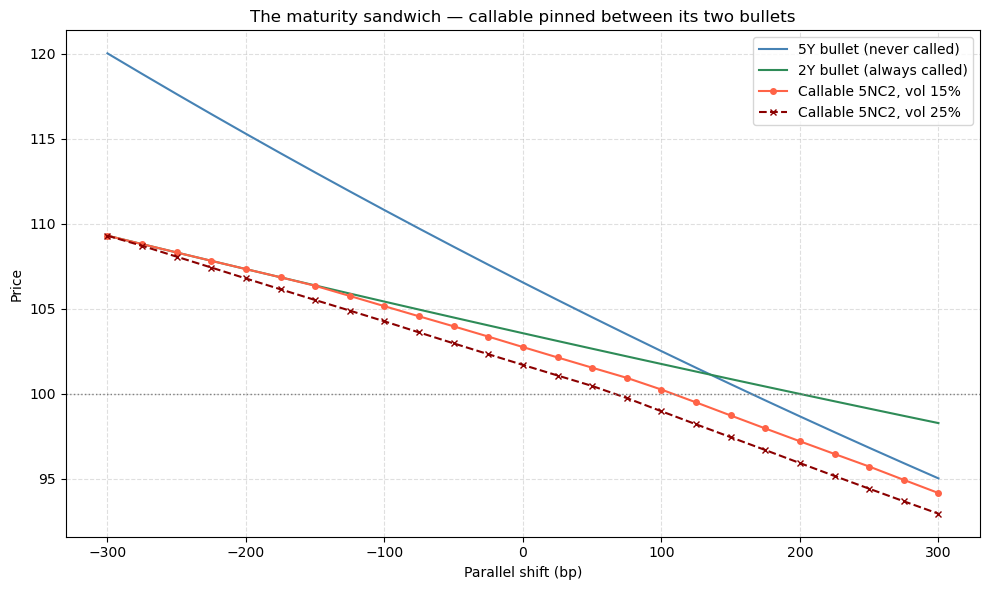

two things to see, both straight from the chapter:
  1. at +300bp the callable hugs the 5Y bullet; at -300bp it bends
     away and converges toward the 2Y — the sandwich.
  2. the 25%-vol curve sits BELOW the 15%-vol curve everywhere:
     more vol = richer short option = cheaper callable. the price
     depends on a parameter we cannot observe directly.


In [47]:
# ── reproducing the 'maturity sandwich' (in the spirit of Exhibit 39-1) ──
# price/yield curves: the 5NC2 callable at two vols, pinned between the
# 2Y bullet (to first call) and the 5Y bullet (to final maturity)
shifts = np.arange(-0.03, 0.0301, 0.0025)

prices_call_15, prices_call_25 = [], []
prices_free5, prices_free2 = [], []
for s in shifts:
    shifted = shift_curve(em_curve, s)
    prices_call_15.append(price_callable(shifted))
    prices_call_25.append(bond_pricer_lattice(COUPON, TENOR, shifted, vol=0.25,
                                              call=True, call_price=CALL_PRICE,
                                              first_call_year=FIRST_CALL))
    prices_free5.append(price_bullet(shifted))
    prices_free2.append(bond_pricer_lattice(COUPON, 2, shifted, VOL))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(shifts * 10000, prices_free5, color="steelblue", linewidth=1.5,
        label="5Y bullet (never called)")
ax.plot(shifts * 10000, prices_free2, color="seagreen", linewidth=1.5,
        label="2Y bullet (always called)")
ax.plot(shifts * 10000, prices_call_15, color="tomato", marker="o",
        markersize=4, label="Callable 5NC2, vol 15%")
ax.plot(shifts * 10000, prices_call_25, color="darkred", linestyle="--",
        marker="x", markersize=4, label="Callable 5NC2, vol 25%")
ax.axhline(100, color="gray", linestyle=":", linewidth=1)
ax.set_title("The maturity sandwich — callable pinned between its two bullets")
ax.set_xlabel("Parallel shift (bp)")
ax.set_ylabel("Price")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("two things to see, both straight from the chapter:")
print("  1. at +300bp the callable hugs the 5Y bullet; at -300bp it bends")
print("     away and converges toward the 2Y — the sandwich.")
print("  2. the 25%-vol curve sits BELOW the 15%-vol curve everywhere:")
print("     more vol = richer short option = cheaper callable. the price")
print("     depends on a parameter we cannot observe directly.")

In [49]:
# ── how much does the vol assumption matter, in points? ──────────
print(f"  {'vol':>5}  {'callable px':>12}  {'option value':>13}")
print("  " + "─" * 34)
for v in [0.05, 0.10, 0.15, 0.20, 0.25]:
    pc = bond_pricer_lattice(COUPON, TENOR, em_curve, vol=v,
                             call=True, call_price=CALL_PRICE,
                             first_call_year=FIRST_CALL)
    pf = bond_pricer_lattice(COUPON, TENOR, em_curve, vol=v)
    print(f"  {v*100:>4.0f}%  {pc:>12.3f}  {pf - pc:>13.3f}")
print("  " + "─" * 34)
print("  15% volatility is an assumption, not a calibration.")
print("  A 5-point change moves the bond price by more than half a point,making volatility calibration a material model limitation.")

    vol   callable px   option value
  ──────────────────────────────────
     5%       103.571          2.985
    10%       103.261          3.294
    15%       102.756          3.799
    20%       102.233          4.323
    25%       101.707          4.848
  ──────────────────────────────────
  15% volatility is an assumption, not a calibration.
  A 5-point change moves the bond price by more than half a point,making volatility calibration a material model limitation.


One more concept before we hedge: **effective maturity**, the maturity of a bullet bond with the same duration as the callable. Our callable's 2.39Y duration places it between a 2Y and 3Y bullet, so it behaves more like a short bond with a tail than a 5-year bond.

In [52]:
# effective maturity: which bullet has the same duration as our callable?
print(f"  {'bullet':>7}  {'eff duration':>13}")
print("  " + "─" * 23)
bullet_durs = []
for m in [2, 3, 4, 5]:
    p0   = bond_pricer_lattice(COUPON, m, em_curve, VOL)
    p_hi = bond_pricer_lattice(COUPON, m, shift_curve(em_curve, +bump), VOL)
    p_lo = bond_pricer_lattice(COUPON, m, shift_curve(em_curve, -bump), VOL)
    d = (p_lo - p_hi) / (2 * p0 * bump)
    bullet_durs.append((m, d))
    print(f"  {m:>6}Y  {d:>12.2f}Y")
print("  " + "─" * 23)

# linear interpolation between the two bracketing bullets
for k in range(len(bullet_durs) - 1):
    m1, d1 = bullet_durs[k]
    m2, d2 = bullet_durs[k + 1]
    if d1 <= eff_dur_call <= d2:
        eff_maturity = m1 + (eff_dur_call - d1) / (d2 - d1) * (m2 - m1)
        break
else:
    eff_maturity = float("nan")

print(f"  callable eff duration : {eff_dur_call:.2f}Y")
print(f"  -> effective maturity : ~{eff_maturity:.1f} years  (5-year final, 2-year call)")

   bullet   eff duration
  ───────────────────────
       2Y          1.77Y
       3Y          2.54Y
       4Y          3.24Y
       5Y          3.89Y
  ───────────────────────
  callable eff duration : 2.39Y
  -> effective maturity : ~2.8 years  (5-year final, 2-year call)


### 8. The KRD : bullet vs callable

Now apply the KRD idea to the tree: bump **one par-curve pillar at a time** by 1bp, rebuild and recalibrate the lattice, and record the price change.

One technical detail: with annual tree steps, a 5-year bond's final cash flow is discounted through the year-4 nodes. As a result, the last risk bucket appears at 4Y and the 5Y pillar carries zero sensitivity.

The important result is the shape. The bullet concentrates risk near the far end of the curve, while the callable concentrates much more risk at the **short end**, because the tree assigns significant probability to an early call.

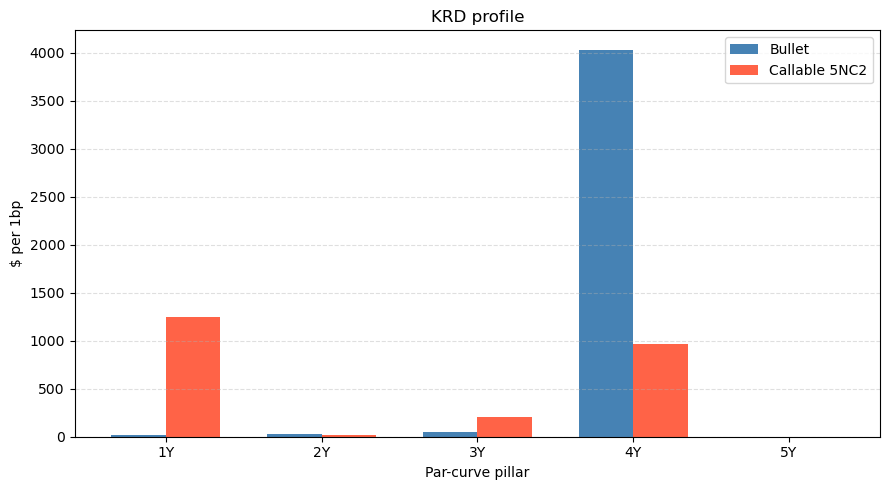

In [55]:
def krd_vector_lattice(pricer, par_rates, notional):
    # bump each par pillar (1Y..5Y) up/down 1bp, one at a time
    krds = []
    for pillar in range(1, TENOR + 1):
        up = list(par_rates)
        dn = list(par_rates)
        up[pillar] += bump
        dn[pillar] -= bump

        krd = (pricer(dn) - pricer(up)) / 2 * (notional / 100)
        krds.append(krd)

    return krds

krd_bond_call = krd_vector_lattice(price_callable, em_curve, NOTIONAL)
krd_bond_free = krd_vector_lattice(price_bullet, em_curve, NOTIONAL)

pillars = [1, 2, 3, 4, 5]
x = np.arange(len(pillars))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x - width / 2, krd_bond_free, width,
       color="steelblue", label="Bullet")
ax.bar(x + width / 2, krd_bond_call, width,
       color="tomato", label="Callable 5NC2")

ax.set_title("KRD profile")
ax.set_xlabel("Par-curve pillar")
ax.set_ylabel("$ per 1bp")
ax.set_xticks(x)
ax.set_xticklabels([f"{p}Y" for p in pillars])
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4, axis="y")

plt.tight_layout()
plt.show()

### 9. Three hedges

Here is the practical problem. Price the EM callable at 106 and its duration sits near 1 year; reprice it at par and the duration roughly triples. **The duration of a callable is not a fixed number. It changes with both rates and credit spreads.** A static interest-rate hedge can therefore only be right for the market conditions in which it was built.

The desk solution is to hedge on a DV01 basis. Use the KRD report from Section 8 to measure the bond's sensitivity at each curve pillar, then pay fixed on enough 1Y, 2Y, ... 5Y swaps to offset those sensitivities. Because KRDs are additive, the same approach will later extend directly to the portfolio.

Equation (39-1) explains the limitation: we are long a bullet and **short a call option**. Vanilla swaps can hedge the bond's rate sensitivity today, but not the optionality that makes that sensitivity change. The hedge therefore needs to be rebalanced as the market moves.

We compare three strategies:

* **Hedge 0: unhedged.** The baseline, with the bond's full rate exposure.
* **Hedge 1: naive hedge.** Assume the bond will be called at 2Y and pay fixed on a 2Y swap for the full $10M notional.
* **Hedge 2: KRD immunization.** Use a strip of pay-fixed swaps sized to offset the bond's KRD at each pillar. I solve from the longest pillar down because longer swaps also carry sensitivity to earlier buckets through their fixed coupons.

In [58]:
def swap_npv(df_curve, tenor, fixed_rate, notional):
    # pay-fixed swap NPV under any curve (positive when rates have risen)
    annuity = 0.0
    for cy in range(1, tenor + 1):
        annuity += get_df(cy, df_curve)
    float_leg = 1.0 - get_df(tenor, df_curve)
    return (float_leg - fixed_rate * annuity) * notional

def swap_krd_vector(tenor, fixed_rate, notional):
    # full-revaluation KRD of the swap on the SOFR curve pillars 1..5
    base = swap_npv(df, tenor, fixed_rate, notional)
    krds = []
    for pillar in [1, 2, 3, 4, 5]:
        krds.append(swap_npv(bump_curve(df, pillar), tenor, fixed_rate, notional) - base)
    return krds

# ── hedge 1: naive — pay fixed 2Y on the full face ───────────────
s2 = price_swap(df, tenor=2, notional=NOTIONAL, verbose=False)
hedge_naive = [(2, s2["par_rate"], NOTIONAL)]

# ── hedge 2: KRD strip — offset each bucket, longest pillar first ─
hedge_strip = []
residual = list(krd_bond_call)

for pillar in [5, 4, 3, 2, 1]:
    if abs(residual[pillar - 1]) < 50:        # ignore noise-level buckets
        continue
    sp = price_swap(df, tenor=pillar, notional=1_000_000, verbose=False)
    unit_krd = swap_krd_vector(pillar, sp["par_rate"], 1_000_000)
    size = residual[pillar - 1] / unit_krd[pillar - 1] * 1_000_000
    hedge_strip.append((pillar, sp["par_rate"], size))
    # subtract this swap's KRD (all buckets) from what is left to hedge
    for i in range(5):
        residual[i] -= unit_krd[i] * size / 1_000_000

def hedge_krd(hedge):
    total = [0.0] * 5
    for tenor_h, k, size in hedge:
        v = swap_krd_vector(tenor_h, k, size)
        for i in range(5):
            total[i] += v[i]
    return total

krd_h1 = hedge_krd(hedge_naive)
krd_h2 = hedge_krd(hedge_strip)

resid_naive = [krd_bond_call[i] - krd_h1[i] for i in range(5)]
resid_strip = [krd_bond_call[i] - krd_h2[i] for i in range(5)]

print("Hedge 1 — naive:")
print(f"   2Y pay-fixed @ {s2['par_rate']*100:.4f}%   notional ${NOTIONAL:,.0f}"
      f"   swap DV01 ${sum(krd_h1):,.0f}")
print(f"   net DV01 vs bond: ${sum(krd_bond_call) - sum(krd_h1):,.0f}")

print("\nHedge 2 — KRD immunization strip:")
for tenor_h, k, size in sorted(hedge_strip):
    print(f"   {tenor_h}Y pay-fixed @ {k*100:.4f}%   notional ${size:,.0f}")
print(f"   strip DV01 ${sum(krd_h2):,.0f}   net DV01 vs bond: "
      f"${sum(krd_bond_call) - sum(krd_h2):,.0f}")

print("\nResidual KRD by pillar ($/bp):")
print(f"  {'Pillar':>7}  {'Bond':>9}  {'Unhedged':>9}  {'Naive':>9}  {'Strip':>9}")
for i, p in enumerate(pillars):
    print(f"  {str(p)+'Y':>7}  ${krd_bond_call[i]:>8,.0f}  ${krd_bond_call[i]:>8,.0f}"
          f"  ${resid_naive[i]:>8,.0f}  ${resid_strip[i]:>8,.0f}")

Hedge 1 — naive:
   2Y pay-fixed @ 3.8500%   notional $10,000,000   swap DV01 $1,963
   net DV01 vs bond: $474

Hedge 2 — KRD immunization strip:
   1Y pay-fixed @ 3.7500%   notional $12,336,956
   3Y pay-fixed @ 3.9800%   notional $651,544
   4Y pay-fixed @ 4.1000%   notional $2,720,255
   strip DV01 $2,447   net DV01 vs bond: $-10

Residual KRD by pillar ($/bp):
   Pillar       Bond   Unhedged      Naive      Strip
       1Y  $   1,247  $   1,247  $   1,210  $      -0
       2Y  $      15  $      15  $  -1,910  $     -10
       3Y  $     210  $     210  $     210  $       0
       4Y  $     964  $     964  $     964  $       0
       5Y  $       0  $       0  $       0  $       0


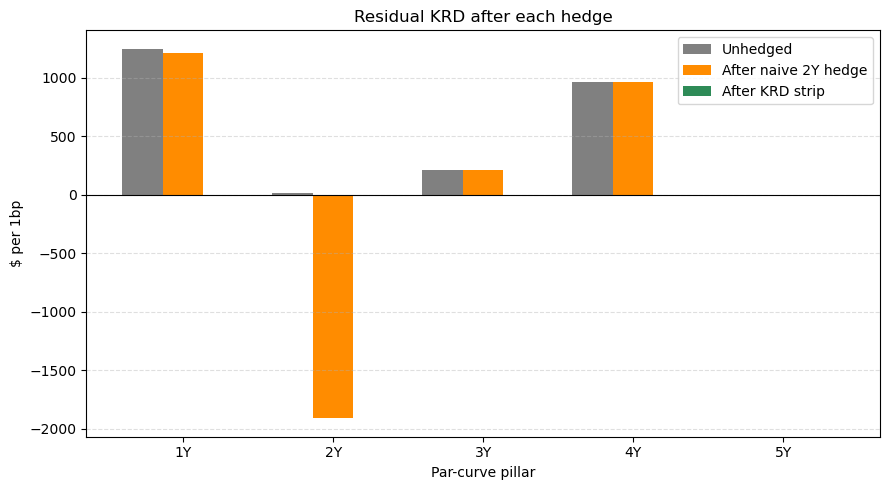

the naive hedge does not just miss — it over-hedges the 2Y bucket
(the callable's risk is NOT at the call date pillar, it is spread
between the very short end and the maturity region) while leaving
the 4Y bucket wide open. the strip flattens everything, today.


In [60]:
# residual risk, visually
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(5)
width = 0.27
ax.bar(x - width, krd_bond_call, width, color="gray",      label="Unhedged")
ax.bar(x,         resid_naive,   width, color="darkorange", label="After naive 2Y hedge")
ax.bar(x + width, resid_strip,   width, color="seagreen",  label="After KRD strip")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Residual KRD after each hedge")
ax.set_xlabel("Par-curve pillar")
ax.set_ylabel("$ per 1bp")
ax.set_xticks(x)
ax.set_xticklabels([f"{p}Y" for p in pillars])
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4, axis="y")
plt.tight_layout()
plt.show()

print("the naive hedge does not just miss — it over-hedges the 2Y bucket")
print("(the callable's risk is NOT at the call date pillar, it is spread")
print("between the very short end and the maturity region) while leaving")
print("the 4Y bucket wide open. the strip flattens everything, today.")

Worth pausing on two things the strip is telling us.

First, the 1Y leg pays fixed on **more than the bond's face** — about \$12.3M against \$10M. The tree is saying that in rate terms this bond mostly behaves like a short-dated instrument (high probability of being called at year 2), and hedging that properly takes more short-end notional than intuition suggests.

Second, and this is the trap, the strip is a **snapshot**. Every notional in it was sized off today's KRD vector, and today's KRD vector was shaped by today's credit spread. Hold that thought: it is what the book level section has to answer for.

That is as far as one bond can take us. We can price the option, locate its risk on the curve, and cancel that risk with swaps. What none of it tells us is what to trade tomorrow morning, because no desk holds one bond. Part III runs the same machinery on a book of four, which is where a KRD report stops describing a security and becomes a trade ticket.

---
## Part III : Immunizing the Book

### 10. DV01 immunization at book level

Everything rests on one fact: **DV01/KRDs are additive.** Compute the report for each bond, sum bucket by bucket, and the whole book's rate risk collapses into a single row of five numbers — telling us how much 1Y, 2Y, …, 5Y swap to trade.

The book below is four EM Berm-style callables with different issuers, coupons, maturities and call schedules.

In [64]:
# the book: (name, coupon, final maturity, first call year, spread, face) ──
PORTFOLIO = [
    ("A  10.0% 5NC2", 0.100, 5, 2, 0.0425, 10_000_000),   # the bond from Part II
    ("B   8.5% 5NC3", 0.085, 5, 3, 0.0300,  8_000_000),
    ("C   9.5% 4NC2", 0.095, 4, 2, 0.0500,  6_000_000),
    ("D   7.5% 3NC1", 0.075, 3, 1, 0.0250, 12_000_000),
]

def price_book_bond(coupon, tenor, first_call, curve):
    # same validated pricer as everywhere else; call every year from first_call
    return bond_pricer_lattice(coupon, tenor, curve, VOL,
                               call=True, call_price=100, first_call_year=first_call)

# each issuer has its own par curve: SOFR + its own credit spread
book_curves = []
book_prices = []
for name, cpn, tenor, fc, spread, face in PORTFOLIO:
    curve = issuer_par_curve(spread)
    book_curves.append(curve)
    book_prices.append(price_book_bond(cpn, tenor, fc, curve))

print(f"  {'bond':<14} {'spread':>7} {'face':>13} {'price':>8} {'mkt value':>13} {'OA-DV01':>9}")
print("  " + "─" * 70)
total_mv, total_dv01 = 0.0, 0.0
book_dv01 = []
for i, (name, cpn, tenor, fc, spread, face) in enumerate(PORTFOLIO):
    # parallel OA-DV01: shift this issuer's whole curve ±1bp, full reval
    up = [r + bump for r in book_curves[i]]
    dn = [r - bump for r in book_curves[i]]
    dv01 = (price_book_bond(cpn, tenor, fc, dn) -
            price_book_bond(cpn, tenor, fc, up)) / 2 * face / 100
    mv = book_prices[i] * face / 100
    book_dv01.append(dv01)
    total_mv += mv
    total_dv01 += dv01
    print(f"  {name:<14} {spread*10000:>5.0f}bp ${face:>12,.0f} {book_prices[i]:>8.3f}"
          f" ${mv:>12,.0f} ${dv01:>8,.0f}")
print("  " + "─" * 70)
print(f"  {'TOTAL':<14} {'':>7} ${sum(b[5] for b in PORTFOLIO):>12,.0f} {'':>8}"
      f" ${total_mv:>12,.0f} ${total_dv01:>8,.0f}")

  bond            spread          face    price     mkt value   OA-DV01
  ──────────────────────────────────────────────────────────────────────
  A  10.0% 5NC2    425bp $  10,000,000  102.756 $  10,275,598 $   2,452
  B   8.5% 5NC3    300bp $   8,000,000  103.653 $   8,292,227 $   2,751
  C   9.5% 4NC2    500bp $   6,000,000  100.341 $   6,020,430 $   1,333
  D   7.5% 3NC1    250bp $  12,000,000  101.173 $  12,140,732 $   2,070
  ──────────────────────────────────────────────────────────────────────
  TOTAL                  $  36,000,000          $  36,728,988 $   8,606


Now the KRD report, bond by bond. One convention to declare: the lattice's very first rate is genuine risk for the *short* bonds — the largest single bucket for the 3NC1 — so I fold it into the 1Y bucket, the short end moving essentially together. On the single 5-year bond it was ~$16 and safely ignored; on a book containing short paper it is not.

In [94]:
def krd_vector_book(coupon, tenor, first_call, curve, face):
    # bump one pillar at a time, +-1bp, full reval — 1Y bucket also carries
    # the tree's first rate (index 0): the short end moves together
    krds = []
    for pillar in range(1, 6):
        up = list(curve)
        dn = list(curve)
        up[pillar] += bump
        dn[pillar] -= bump
        if pillar == 1:
            up[0] += bump
            dn[0] -= bump
        k = (price_book_bond(coupon, tenor, first_call, dn) -
             price_book_bond(coupon, tenor, first_call, up)) / 2 * face / 100
        krds.append(k)
    return krds

book_krd = []
for i, (name, cpn, tenor, fc, spread, face) in enumerate(PORTFOLIO):
    book_krd.append(krd_vector_book(cpn, tenor, fc, book_curves[i], face))

agg_krd = [0.0] * 5
for kv in book_krd:
    for j in range(5):
        agg_krd[j] += kv[j]

print(f"  KRD report ($ per 1bp):")
print(f"  {'bond':<14} {'1Y':>8} {'2Y':>8} {'3Y':>8} {'4Y':>8} {'5Y':>8} {'sum':>9}")
print("  " + "─" * 62)
for i, (name, cpn, tenor, fc, spread, face) in enumerate(PORTFOLIO):
    kv = book_krd[i]
    print(f"  {name:<14} " + " ".join(f"{k:>8,.0f}" for k in kv) + f" {sum(kv):>9,.0f}")
print("  " + "─" * 62)
print(f"  {'PORTFOLIO':<14} " + " ".join(f"{k:>8,.0f}" for k in agg_krd)
      + f" {sum(agg_krd):>9,.0f}")

gap = abs(sum(agg_krd) - total_dv01)
print()
print("  note how differently the risk is distributed: the 3NC1 lives at the")
print("  short end, the 5NC3 out at the wing — the AGGREGATE row is the only")
print("  thing the hedge needs to see.")

  KRD report ($ per 1bp):
  bond                 1Y       2Y       3Y       4Y       5Y       sum
  ──────────────────────────────────────────────────────────────
  A  10.0% 5NC2     1,263       15      210      964        0     2,452
  B   8.5% 5NC3        29      882      511    1,330        0     2,751
  C   9.5% 4NC2       659        4      681        0        0     1,344
  D   7.5% 3NC1     1,049    1,021        0        0        0     2,070
  ──────────────────────────────────────────────────────────────
  PORTFOLIO         2,999    1,922    1,402    2,294        0     8,617

  note how differently the risk is distributed: the 3NC1 lives at the
  short end, the 5NC3 out at the wing — the AGGREGATE row is the only
  thing the hedge needs to see.


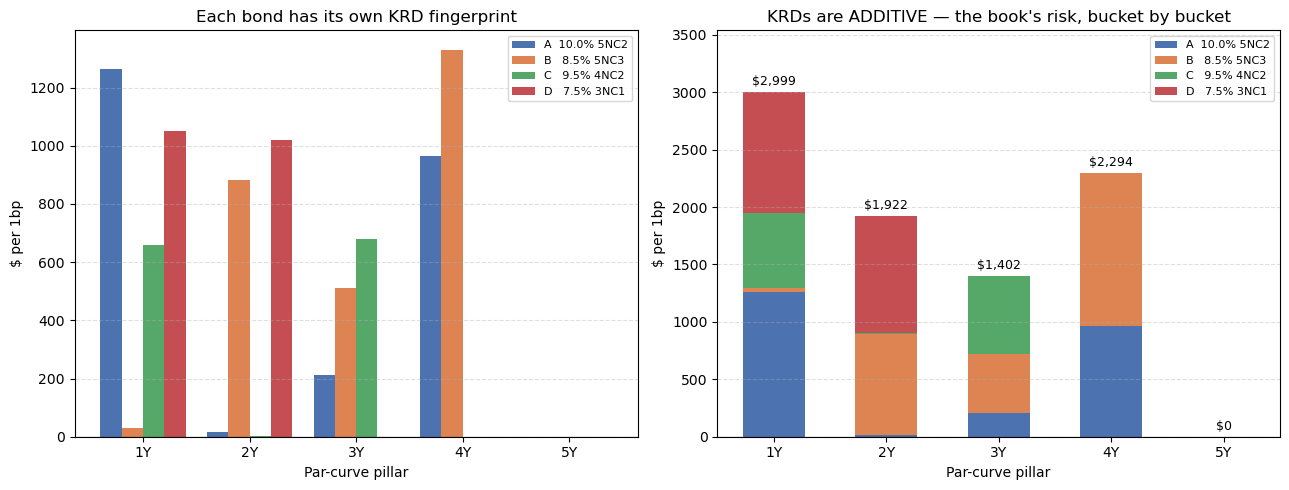

left: four bonds, four different risk shapes.
right: stack the same KRDs and the whole book becomes one hedge vector.


In [100]:
# ── the additivity picture ──
labels = []
for name, cpn, tenor, fc, spread, face in PORTFOLIO:
    labels.append(name.strip())
bond_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
x = np.arange(5)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

# left: each bond on its own — every one a different shape
width = 0.2
for b in range(4):
    axL.bar(x + (b - 1.5) * width, book_krd[b], width,
            color=bond_colors[b], label=labels[b])
axL.axhline(0, color="black", linewidth=0.8)
axL.set_title("Each bond has its own KRD fingerprint")
axL.set_xlabel("Par-curve pillar")
axL.set_ylabel("$ per 1bp")
axL.set_xticks(x)
axL.set_xticklabels(["1Y", "2Y", "3Y", "4Y", "5Y"])
axL.legend(fontsize=8)
axL.grid(True, linestyle="--", alpha=0.4, axis="y")

# right: stack them — this is what the hedge actually sees
bottom = np.zeros(5)
for b in range(4):
    axR.bar(x, book_krd[b], 0.55, bottom=bottom,
            color=bond_colors[b], label=labels[b])
    for j in range(5):
        bottom[j] += book_krd[b][j]
axR.axhline(0, color="black", linewidth=0.8)
for j in range(5):
    axR.text(j, bottom[j] + 60, f"${bottom[j]:,.0f}", ha="center", fontsize=9)
axR.set_title("KRDs are ADDITIVE — the book's risk, bucket by bucket")
axR.set_xlabel("Par-curve pillar")
axR.set_ylabel("$ per 1bp")
axR.set_xticks(x)
axR.set_xticklabels(["1Y", "2Y", "3Y", "4Y", "5Y"])
axR.set_ylim(0, max(bottom) * 1.18)
axR.legend(fontsize=8)
axR.grid(True, linestyle="--", alpha=0.4, axis="y")

plt.tight_layout()
plt.show()

print("left: four bonds, four different risk shapes.")
print("right: stack the same KRDs and the whole book becomes one hedge vector.")

**Immunizing the book** is the *same* algorithm as Section 9 — solve from the longest pillar down, one pay-fixed swap per bucket — now fed the aggregate row instead of a single bond's.

In [103]:
# ── build the portfolio strip on the aggregate KRD vector ──
port_strip = []
residual = list(agg_krd)
for pillar in [5, 4, 3, 2, 1]:
    if abs(residual[pillar - 1]) < 1:
        continue
    sp = price_swap(df, tenor=pillar, notional=1_000_000, verbose=False)
    unit_krd = swap_krd_vector(pillar, sp["par_rate"], 1_000_000)
    size = residual[pillar - 1] / unit_krd[pillar - 1] * 1_000_000
    port_strip.append((pillar, sp["par_rate"], size))
    for j in range(5):
        residual[j] -= unit_krd[j] * size / 1_000_000

print(f"  the portfolio hedge — {len(port_strip)} swaps for {len(PORTFOLIO)} bonds:")
print("  (no 5Y swap: the book carries no risk at that pillar — see the KRD row)")
for tenor, k, size in sorted(port_strip):
    print(f"    {tenor}Y pay-fixed @ {k*100:.4f}%   notional ${size:>12,.0f}")

krd_port_strip = [0.0] * 5
for tenor, k, size in port_strip:
    v = swap_krd_vector(tenor, k, size)
    for j in range(5):
        krd_port_strip[j] += v[j]

print()
print(f"  {'':<12} {'1Y':>8} {'2Y':>8} {'3Y':>8} {'4Y':>8} {'5Y':>8}")
print(f"  {'book KRD':<12} " + " ".join(f"{k:>8,.0f}" for k in agg_krd))
print(f"  {'strip KRD':<12} " + " ".join(f"{k:>8,.0f}" for k in krd_port_strip))
print(f"  {'residual':<12} " + " ".join(f"{agg_krd[j]-krd_port_strip[j]:>8,.0f}" for j in range(5)))

  the portfolio hedge — 4 swaps for 4 bonds:
  (no 5Y swap: the book carries no risk at that pillar — see the KRD row)
    1Y pay-fixed @ 3.7500%   notional $  29,199,765
    2Y pay-fixed @ 3.8500%   notional $   9,540,303
    3Y pay-fixed @ 3.9800%   notional $   4,799,570
    4Y pay-fixed @ 4.1000%   notional $   6,473,868

                     1Y       2Y       3Y       4Y       5Y
  book KRD        2,999    1,922    1,402    2,294        0
  strip KRD       2,999    1,922    1,402    2,294        0
  residual            0        0        0        0        0


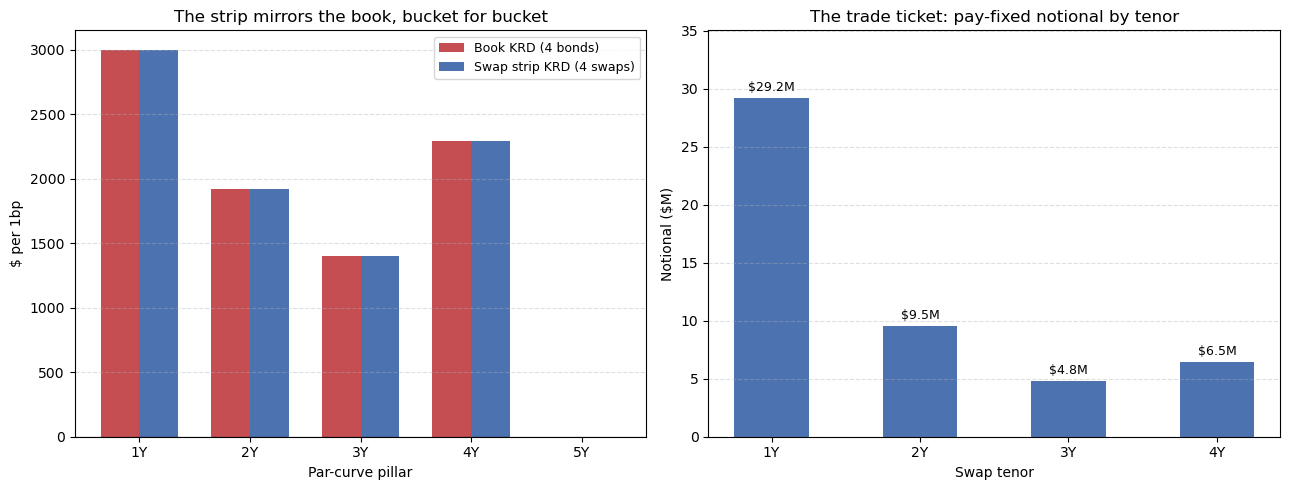

left: the swap strip mirrors the book bucket by bucket, leaving essentially no first-order rate risk.
right: four tradeable hedge notionals, with the largest at 1Y where the callable book concentrates most of its duration.


In [107]:
# ── the immunization, visually ──
resid_port = []
for j in range(5):
    resid_port.append(agg_krd[j] - krd_port_strip[j])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

# left: book risk vs the swap strip that mirrors it
width = 0.35
axL.bar(x - width / 2, agg_krd, width, color="#C44E52", label="Book KRD (4 bonds)")
axL.bar(x + width / 2, krd_port_strip, width, color="#4C72B0",
        label=f"Swap strip KRD ({len(port_strip)} swaps)")
axL.axhline(0, color="black", linewidth=0.8)
axL.set_title("The strip mirrors the book, bucket for bucket")
axL.set_xlabel("Par-curve pillar")
axL.set_ylabel("$ per 1bp")
axL.set_xticks(x)
axL.set_xticklabels(["1Y", "2Y", "3Y", "4Y", "5Y"])
axL.legend(fontsize=9)
axL.grid(True, linestyle="--", alpha=0.4, axis="y")

# right: the actual trade ticket this analysis produces
strip_tenors = []
strip_sizes = []
for tenor, k, size in sorted(port_strip):
    strip_tenors.append(f"{tenor}Y")
    strip_sizes.append(size / 1e6)
axR.bar(strip_tenors, strip_sizes, 0.5, color="#4C72B0")
for i in range(len(strip_sizes)):
    axR.text(i, strip_sizes[i] + 0.6, f"${strip_sizes[i]:,.1f}M",
             ha="center", fontsize=9)
axR.set_title("The trade ticket: pay-fixed notional by tenor")
axR.set_xlabel("Swap tenor")
axR.set_ylabel("Notional ($M)")
axR.set_ylim(0, max(strip_sizes) * 1.2)
axR.grid(True, linestyle="--", alpha=0.4, axis="y")

plt.tight_layout()
plt.show()

print("left: the swap strip mirrors the book bucket by bucket, leaving essentially no first-order rate risk.")
print("right: four tradeable hedge notionals, with the largest at 1Y where the callable book concentrates most of its duration.")

Now we put a dollar figure on what that strip actually removed.

Full disclosure: before this project I had never computed a Value at Risk. I had only seen the finished number on other people's slides. So this part spells the mechanics out at the level I wish someone had spelled them out for me, and then applies them to the book we just hedged.

**The question VaR answers.** "How much could we lose on a genuinely bad day?" Formally, the 99% one day VaR is the loss threshold that hypothetical daily P&L exceeds only 1% of the time. It is a percentile of a distribution, nothing deeper.

**Where does the distribution come from?** We use *historical simulation*, the most transparent method on any desk:

1. Collect a history of daily market moves, say 500 days of "the 2Y rate rose 3bp, the 5Y rose 4bp, the spread tightened 6bp".
2. Take **today's** book and ask: if that day happened again tomorrow, what would my P&L be? Apply the day's moves to today's curves and reprice everything. For four callables that means four fresh tree builds per scenario, which is why the `brentq` calibration had to be quick.
3. That gives 500 hypothetical daily P&Ls, an empirical distribution inheriting whatever correlations and fat tails the history had, with no normality assumption anywhere.
4. Sort them. The 1st percentile is the 99% VaR.
5. The average of the days beyond that cutoff is the **Expected Shortfall**: when the bad day comes, how bad is it on average?

**Two risk factors, simulated separately**, the same split a big bond desk computes daily:

* **Rate moves**, a common level factor plus idiosyncratic pillar noise, around 5 to 6bp a day. The swap strip offsets these.
* **Spread moves**, around 8bp a day, EM appropriate. **Nothing in the vanilla swap market offsets these**, because no swap references an issuer's credit.

Keeping the two apart is not cosmetic. It is the only way to see what the strip actually did, for a reason the numbers below will make obvious.

I had originally planned to pull the DGS2/5/7/10 series from FRED for the rate factor. To keep the notebook reproducible offline I simulate the history instead (seeded), with realistic vols and correlation. Swapping in the FRED CSVs is a direct substitution, since the loop does not care where the daily moves came from.

**One caveat to carry through everything below.** Because that history is generated from Gaussian factors I chose, every VaR here is a conditional statement: the risk of this book *under the illustrative synthetic factor calibration used here*, not an empirical estimate of what these bonds would have lost in any real 500 day window. The machinery is exactly what a desk runs. The distribution it is fed is mine. So the correct way to quote any number below is "so many dollars of 99% VaR under the synthetic calibration", never "the book has that much VaR". What survives a change of calibration is the *structure* of the result: that spread risk dominates, that the two factors do not add, and that hedging moves one component and not the other.

In [77]:
# ── the scenario history: 500 days of curve moves ────────────────
rng = np.random.default_rng(42)
n_days = 500                                  # ~2 years of daily moves

# rate factor: common level move + small idiosyncratic noise per pillar
common = rng.normal(0, 0.00050, n_days)
rate_moves = {}
pillar_specs = [(1, 0.8, 0.00025), (2, 0.9, 0.00020), (3, 1.0, 0.00018),
                (4, 1.0, 0.00018), (5, 1.0, 0.00020)]
for pillar, beta, idio in pillar_specs:
    rate_moves[pillar] = beta * common + rng.normal(0, idio, n_days)

# spread factor: hits the bond only
spread_moves = rng.normal(0, 0.00080, n_days)

# what does one 'scenario' actually look like? here are the first five:
print("  the raw material — daily curve moves in basis points:")
print(f"  {'day':>4} {'1Y':>6} {'2Y':>6} {'3Y':>6} {'4Y':>6} {'5Y':>6} {'spread':>7}")
print("  " + "─" * 45)
for i in range(5):
    row = [rate_moves[p][i] * 10000 for p in range(1, 6)]
    print(f"  {i:>4} {row[0]:>+6.1f} {row[1]:>+6.1f} {row[2]:>+6.1f}"
          f" {row[3]:>+6.1f} {row[4]:>+6.1f} {spread_moves[i]*10000:>+7.1f}")
print("  " + "─" * 45)
print(f"  ...and {n_days - 5} more. each row is one question: 'if this")
print("  happened tomorrow, what would today's book lose?'")

def var99(pnl):
    return -np.percentile(pnl, 1)

def es99(pnl):
    v = var99(pnl)
    tail = pnl[pnl <= -v]
    return -tail.mean() if len(tail) > 0 else v

  the raw material — daily curve moves in basis points:
   day     1Y     2Y     3Y     4Y     5Y  spread
  ─────────────────────────────────────────────
     0   +4.6   +1.3   +0.5   +0.7   +2.6   +10.0
     1   -1.9   -6.1   -6.3   -6.4   -4.7    +5.5
     2   +1.2   +2.5   +6.1   +4.5   +5.8   +15.7
     3   +0.0   +5.5   +5.3   +5.2   +5.7   -12.4
     4  -15.2   -8.8  -10.1  -12.3   -7.3    -2.1
  ─────────────────────────────────────────────
  ...and 495 more. each row is one question: 'if this
  happened tomorrow, what would today's book lose?'


Now run it. One simplification to be upfront about: I move all four issuers' spreads with a *single* common EM spread factor. Real spreads are imperfectly correlated, which would give some diversification across issuers — so my spread VaR is, if anything, on the conservative side.

In [80]:
# ── portfolio VaR: full reval of the BONDS; swaps enter first-order ──
# (each bond gets a fresh tree per scenario; the swaps are linear instruments
#  so their P&L is KRD x move — accurate for daily-sized shocks, not for stress)
def run_portfolio_sim(use_rates, use_spread):
    # returns P&L arrays for (unhedged book, strip-hedged book)
    pnl_u, pnl_h = [], []
    for i in range(n_days):
        bond_pnl = 0.0
        for b, (name, cpn, tenor, fc, spread, face) in enumerate(PORTFOLIO):
            shifted = list(book_curves[b])
            for pillar in range(1, 6):
                if use_rates:
                    shifted[pillar] += rate_moves[pillar][i]
                if use_spread:
                    shifted[pillar] += spread_moves[i]
            if use_rates:
                shifted[0] += rate_moves[1][i]    # short end moves with 1Y
            if use_spread:
                shifted[0] += spread_moves[i]
            p_new = price_book_bond(cpn, tenor, fc, shifted)
            bond_pnl += (p_new - book_prices[b]) * face / 100

        sw = 0.0
        if use_rates:
            for pillar in range(1, 6):
                sw += krd_port_strip[pillar - 1] * (rate_moves[pillar][i] / bump)

        pnl_u.append(bond_pnl)
        pnl_h.append(bond_pnl + sw)
    return np.array(pnl_u), np.array(pnl_h)

port_total  = run_portfolio_sim(True, True)
port_rate   = run_portfolio_sim(True, False)
port_spread = run_portfolio_sim(False, True)

face_total = sum(b[5] for b in PORTFOLIO)
print(f"  99% daily VaR — ${face_total/1e6:.0f}M four-bond book, {n_days} scenarios")
print("  (bonds fully revalued on the lattice; swap P&L first-order via KRD)")
print("  " + "─" * 62)
print(f"  {'':<16} {'rate VaR':>11} {'spread VaR':>11} {'total VaR':>11} {'total ES':>11}")
for k, label in [(0, "unhedged"), (1, "strip-hedged")]:
    print(f"  {label:<16} ${var99(port_rate[k]):>10,.0f} ${var99(port_spread[k]):>10,.0f}"
          f" ${var99(port_total[k]):>10,.0f} ${es99(port_total[k]):>10,.0f}")
print("  " + "─" * 62)

# where does that unhedged total VaR actually come from? read it by hand:
worst = np.sort(port_total[0])
print()
print("  the five worst days out of 500, unhedged book:")
for k in range(5):
    print(f"    #{k+1}:  ${worst[k]:>11,.0f}")
print(f"    #6:  ${worst[5]:>11,.0f}")
print("  1% of 500 days = 5 days, so the 99% VaR sits between #5 and #6:")
print(f"    99% VaR = ${var99(port_total[0]):,.0f}")
print(f"    99% ES  = ${es99(port_total[0]):,.0f}   (mean of the tail beyond it)")
print()
red = (1 - var99(port_rate[1]) / var99(port_rate[0])) * 100
print(f"  rate-VaR reduction from the strip: {red:.0f}%")
print(f"  spread VaR untouched — that risk is the mandate, and no vanilla")
print(f"  swap references any of these issuers' credit.")

  99% daily VaR — $36M four-bond book, 500 scenarios
  (bonds fully revalued on the lattice; swap P&L first-order via KRD)
  ──────────────────────────────────────────────────────────────
                      rate VaR  spread VaR   total VaR    total ES
  unhedged         $    97,819 $   168,144 $   183,670 $   219,975
  strip-hedged     $     5,007 $   168,144 $   170,719 $   199,328
  ──────────────────────────────────────────────────────────────

  the five worst days out of 500, unhedged book:
    #1:  $   -266,933
    #2:  $   -226,136
    #3:  $   -216,654
    #4:  $   -197,444
    #5:  $   -192,706
    #6:  $   -183,579
  1% of 500 days = 5 days, so the 99% VaR sits between #5 and #6:
    99% VaR = $183,670
    99% ES  = $219,975   (mean of the tail beyond it)

  rate-VaR reduction from the strip: 95%
  spread VaR untouched — that risk is the mandate, and no vanilla
  swap references any of these issuers' credit.


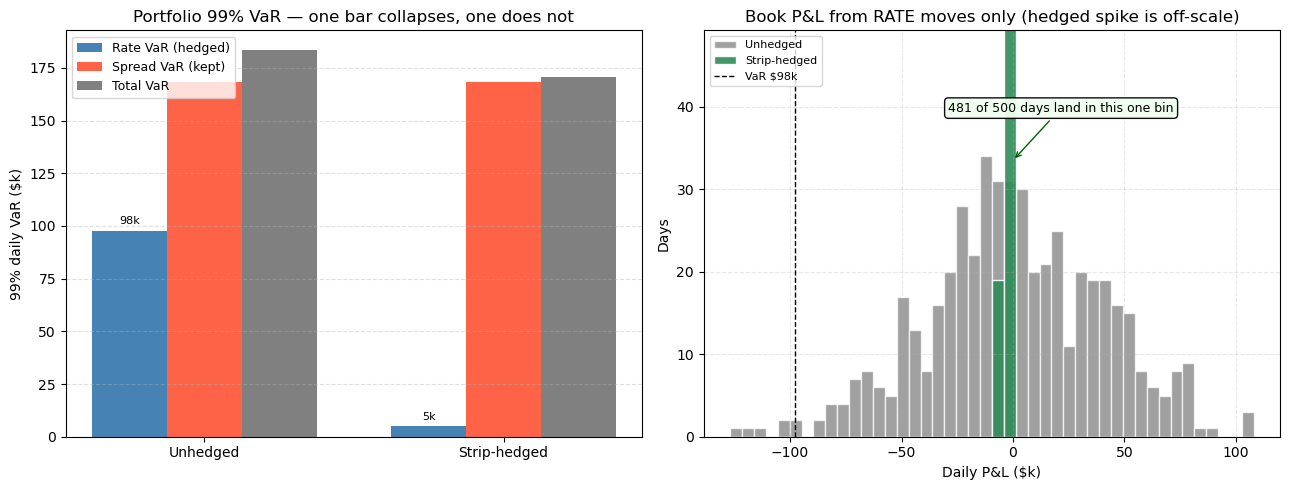

right: the unhedged book moves with the curve; after four swaps, rate moves barely register. this is DV01 immunization at portfolio level.


In [111]:
# ── portfolio VaR: the decomposition, then the distributions ──
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

# left: which bar the hedge actually moves
xv = np.arange(2)
width = 0.25
rate_v   = [var99(port_rate[k])   / 1000 for k in range(2)]
spread_v = [var99(port_spread[k]) / 1000 for k in range(2)]
total_v  = [var99(port_total[k])  / 1000 for k in range(2)]
axL.bar(xv - width, rate_v,   width, color="steelblue", label="Rate VaR (hedged)")
axL.bar(xv,         spread_v, width, color="tomato",    label="Spread VaR (kept)")
axL.bar(xv + width, total_v,  width, color="gray",      label="Total VaR")
for i in range(2):
    axL.text(i - width, rate_v[i] + 3, f"{rate_v[i]:,.0f}k", ha="center", fontsize=8)
axL.set_title("Portfolio 99% VaR — one bar collapses, one does not")
axL.set_ylabel("99% daily VaR ($k)")
axL.set_xticks(xv)
axL.set_xticklabels(["Unhedged", "Strip-hedged"])
axL.legend(fontsize=9)
axL.grid(True, linestyle="--", alpha=0.4, axis="y")

# right: the rate-risk distribution before and after, on shared bins
edges = np.linspace(min(port_rate[0].min(), port_rate[1].min()) / 1000,
                    max(port_rate[0].max(), port_rate[1].max()) / 1000, 45)
cnt_u, _, _ = axR.hist(port_rate[0] / 1000, bins=edges, color="gray", alpha=0.75,
                       edgecolor="white", label="Unhedged")
cnt_h, _, _ = axR.hist(port_rate[1] / 1000, bins=edges, color="seagreen", alpha=0.9,
                       edgecolor="white", label="Strip-hedged")
axR.axvline(-var99(port_rate[0]) / 1000, color="black", linestyle="--",
            linewidth=1, label=f"VaR ${var99(port_rate[0])/1000:,.0f}k")
# the hedged spike is several times taller than the unhedged bell: clip the
# axis to the bell and label the spike instead of squashing everything flat
top = max(cnt_u) * 1.45
axR.set_ylim(0, top)
spike_note = f"{int(max(cnt_h))} of {n_days} days land in this one bin"
axR.annotate(spike_note,
             xy=(0, top * 0.68), xytext=(0.62, 0.80), textcoords="axes fraction",
             fontsize=9, ha="center",
             arrowprops=dict(arrowstyle="->", color="darkgreen"),
             bbox=dict(boxstyle="round", facecolor="honeydew", alpha=0.95))
axR.set_title("Book P&L from RATE moves only (hedged spike is off-scale)")
axR.set_xlabel("Daily P&L ($k)")
axR.set_ylabel("Days")
axR.legend(fontsize=8, loc="upper left")
axR.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

print("right: the unhedged book moves with the curve; after four swaps, rate moves barely register. this is DV01 immunization at portfolio level.")

One discipline before accepting that number: a VaR nobody checks is just a number. The standard test is **backtesting** — count how often the realized daily loss actually exceeded the VaR. At 99% confidence you expect about 2.5 exceptions per 250 trading days; many more means the model understates risk. The Basel "traffic light" makes this supervisory: 0–4 exceptions is green, 5–9 yellow (your capital multiplier rises), 10+ red (model rejected).

**Read what follows as an illustration of the mechanics, not as validation of the model.** My VaR is computed on the same 500 synthetic days it is then tested against, and those days were generated from the very distribution the percentile describes. Asking whether that data is consistent with its own percentile is close to circular — it would be surprising if it were not. A real backtest uses a rolling out-of-sample window and, ideally, realized market history the model never saw. What this cell genuinely teaches is what an exception *is* and how a regulator counts them.

In [113]:
# backtest the hedged book's VaR: count exceptions, Basel traffic-light style
hedged = port_total[1]
v = var99(hedged)
last_250 = hedged[-250:]

exceptions = 0
for pnl in last_250:
    if pnl < -v:            # an 'exception': the day lost more than VaR predicted
        exceptions += 1

if exceptions <= 4:
    zone = "GREEN"
elif exceptions <= 9:
    zone = "YELLOW"
else:
    zone = "RED"

print(f"  strip-hedged book, last 250 days: {exceptions} exception(s) vs 99% VaR")
print(f"  expected at 99% confidence      : ~2.5")
print(f"  Basel traffic-light zone        : {zone}  (green 0-4, yellow 5-9, red 10+)")
print()
print("  caveat: this is an in-sample backtest; production VaR would be tested on a rolling out-of-sample window.")

  strip-hedged book, last 250 days: 2 exception(s) vs 99% VaR
  expected at 99% confidence      : ~2.5
  Basel traffic-light zone        : GREEN  (green 0-4, yellow 5-9, red 10+)

  caveat: this is an in-sample backtest; production VaR would be tested on a rolling out-of-sample window.


**What did this hedge cost, and what is still open?** The cleaner hedge for a Bermudan callable is a Bermudan swaption, but that means paying an option premium and accepting much thinner liquidity. Vanilla swaps are cheap and liquid, but they are **linear**. They hedge today's rate sensitivity, not the option that makes that sensitivity change.

Two things make the hedge decay:

* **Rates move, so gamma bites.** In a rally, calls move into the money, duration compresses, and the original swap strip becomes too large.
* **Spreads move, so duration moves without rates moving.** Wider spreads make calls less likely, extend the bonds' duration, and leave the existing strip too small even though the swaps themselves show no P&L.

The real cost of the cheap hedge is therefore not the upfront premium but the **need to rebalance over time**.

   spread drift   book DV01  strip DV01   mismatch
  ────────────────────────────────────────────────
            0bp $     8,606 $     8,617 $      -11
           25bp $     8,865 $     8,617 $      248
           50bp $     8,774 $     8,617 $      157
          100bp $     9,273 $     8,617 $      656
          150bp $     9,519 $     8,617 $      902
          200bp $    10,075 $     8,617 $    1,458
          300bp $    10,128 $     8,617 $    1,511
  ────────────────────────────────────────────────


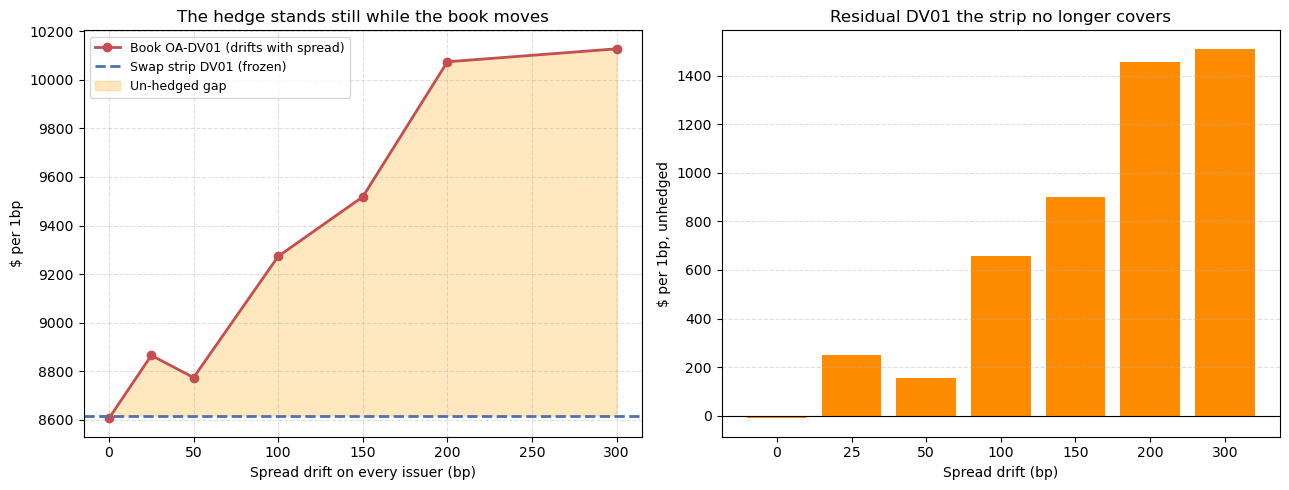

  rates did not move, but wider spreads made the callables longer and increased their DV01.
  the swap strip stayed unchanged, so the book is no longer fully hedged and must be rebalanced.


In [117]:
# ── and the gamma is still there: the book's DV01 drifts, the strip does not ──
# widen every issuer's spread, rebalance NOTHING, watch the gap open
drifts = [0, 25, 50, 100, 150, 200, 300]
book_dv01_path = []
for d in drifts:
    agg = 0.0
    for b, (name, cpn, tenor, fc, spread, face) in enumerate(PORTFOLIO):
        drifted = [r + d / 10000.0 for r in book_curves[b]]
        up = [r + bump for r in drifted]
        dn = [r - bump for r in drifted]
        agg += (price_book_bond(cpn, tenor, fc, dn) -
                price_book_bond(cpn, tenor, fc, up)) / 2 * face / 100
    book_dv01_path.append(agg)

strip_dv01 = sum(krd_port_strip)

print(f"  {'spread drift':>13} {'book DV01':>11} {'strip DV01':>11} {'mismatch':>10}")
print("  " + "─" * 48)
for i in range(len(drifts)):
    print(f"  {drifts[i]:>11}bp ${book_dv01_path[i]:>10,.0f} ${strip_dv01:>10,.0f}"
          f" ${book_dv01_path[i] - strip_dv01:>9,.0f}")
print("  " + "─" * 48)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

axL.plot(drifts, book_dv01_path, "o-", color="#C44E52", linewidth=2,
         label="Book OA-DV01 (drifts with spread)")
axL.axhline(strip_dv01, color="#4C72B0", linewidth=2, linestyle="--",
            label="Swap strip DV01 (frozen)")
axL.fill_between(drifts, book_dv01_path, strip_dv01, color="orange", alpha=0.25,
                 label="Un-hedged gap")
axL.set_title("The hedge stands still while the book moves")
axL.set_xlabel("Spread drift on every issuer (bp)")
axL.set_ylabel("$ per 1bp")
axL.legend(fontsize=9)
axL.grid(True, linestyle="--", alpha=0.4)

mismatch = []
for i in range(len(drifts)):
    mismatch.append(book_dv01_path[i] - strip_dv01)
axR.bar([str(d) for d in drifts], mismatch, color="darkorange")
axR.axhline(0, color="black", linewidth=0.8)
axR.set_title("Residual DV01 the strip no longer covers")
axR.set_xlabel("Spread drift (bp)")
axR.set_ylabel("$ per 1bp, unhedged")
axR.grid(True, linestyle="--", alpha=0.4, axis="y")

plt.tight_layout()
plt.show()

print("  rates did not move, but wider spreads made the callables longer and increased their DV01.")
print("  the swap strip stayed unchanged, so the book is no longer fully hedged and must be rebalanced.")

### 11. Limitations of the model

Reading the source chapters carefully is also how you learn what your own implementation is *not* doing. Everything below is a conscious simplification, and most of them are inherited directly from assumptions the chapters themselves flag.

**Constant volatility.** The lattice assumes a *stationary* volatility — one number, 15%, forever and at every rate level. Real rate volatility has a term structure and a smile, and desks calibrate trees to the swaption surface rather than assuming a number. My own Section 7 table shows the price moves more than half a point per 5 vol points — so the single most price-sensitive input in this notebook is the one I made up. Chapter 39 makes the same point graphically: the callable's entire price/yield curve shifts with vol.

**One factor, and it is the wrong count.** The tree models the short rate only. But the entire thesis of this project is that the call decision depends on *two* stochastic factors — rates and spread. I handle the spread by shifting the issuer curve exogenously (scenarios, VaR factors), which captures the level effect but not the dynamics: no spread mean-reversion, no rate–spread correlation inside the tree, and the call boundary never sees spread *uncertainty*, only spread *levels*. A production model for this problem would be two-factor by construction.

**Credit enters as a spread, never as a default — this is the deepest simplification in the notebook.** I build each issuer curve as

$$\text{issuer par rate} = \text{SOFR par rate} + \text{flat spread}$$

which represents credit as nothing more than a continuously shifted interest-rate curve. Stated plainly, the model contains **no hazard rate, no probability of default, no recovery assumption, no survival probability, no CDS curve, and no stochastic default event.** A proper risky-bond framework would discount *survival-weighted* cash flows and add a recovery payoff on default; mine discounts certain cash flows at a higher rate, which is a different object that happens to price similarly for small spread moves.

The naming consequence matters, and I have tried to be consistent about it everywhere in this notebook: what I compute is **spread VaR — mark-to-market spread-repricing risk — and never credit VaR.** It answers "what if the market reprices this issuer's spread by 8bp tomorrow," not "what if this issuer defaults." Those are different distributions: spread repricing is roughly symmetric day to day, while actual credit loss is skewed and fat-tailed, with most of its mass at zero and a long left tail no Gaussian spread shock can reach. For a mandate whose whole point is warehousing credit risk, the number I report is therefore a floor on the true risk, not a measure of it.

**Annual time steps.** The chapter itself warns that step size is "critical" in practice. With one-year steps my Bermudan is exercisable once a year (real ones are usually quarterly or continuous after first call), the exercise boundary is coarse, and the 5Y cash flow's risk lands on the 4Y pillar of the KRD grid. Finer steps are a mechanical change — the recursion does not care — but every tree rebuild gets proportionally slower, which matters at 3,000 rebuilds per VaR run.

**Constant-OAS bumping.** The effective-duration recipe holds OAS fixed while the curve shifts (step 4 of the chapter's procedure). Empirically, spreads are correlated with rates — OAS is anything but constant through a 200bp move. Chapter 39's warning that OAS "by itself may not provide sufficient information" is the polite version of this.

**The call rule is purely financial.** `min(call price, PV)` assumes the issuer refinances the instant it is economic to do so. Real issuers face issuance costs, documentation lags, ratings and accounting considerations — they call late, and occasionally early. A refinancing-friction model would soften the exercise boundary that my hedges are so sensitive to.

**The VaR is honest about being synthetic.** Simulated (seeded) history rather than actual FRED/CDS data, swap P&L linearized through KRDs, VaR tested in-sample, no transaction costs, and no simulation of the *rebalancing policy* that Section 10 shows is the actual risk-management decision. Each of these is a straightforward extension; together they are the difference between a study and a production system.

None of this changes the qualitative conclusion — the two-factor structure of the residual risk survives every one of these refinements, because it is a property of the *instrument*, not of the model. But the numbers would move, and knowing in which direction is exactly the kind of question a desk quant gets paid to answer.

---
## Conclusion

**The result, 99% daily VaR on the \$36M four-bond book:**

| Book | Rate VaR | Spread VaR | Total VaR |
|:---|---:|---:|---:|
| Unhedged | \$97.8k | \$168.1k | \$183.7k |
| Immunized with 4 vanilla swaps | **\$5.0k** | \$168.1k | \$170.7k |

Four liquid trades remove **95% of the book's interest rate risk** while leaving direct spread exposure essentially unchanged.

**1. A callable is a bond and a short swaption, and the swaption ignores your hedge.** The EM 5NC2 carries an OA-DV01 of USD 2,452 against USD 4,145 for the same bond without the call, so 59% of the bullet's rate risk. That ratio is not constant. It depends on where rates and spreads happen to be.

**2. The naive hedge fails at the wrong pillar, not at the wrong size.** The lattice puts the callable's risk at the 1Y bucket (USD 1,247) and almost none at the 2Y call date (USD 15). A single 2Y swap sized on total DV01 therefore leaves USD 1,210 unhedged at 1Y while creating a USD 1,910 short at 2Y. Only bucketed sensitivities make that visible.

**3. KRD immunization works at book level because KRDs are additive.** Four callables with different call schedules put their risk in different places on the curve. Summing their KRDs collapses the book into one risk vector that four vanilla swaps offset bucket by bucket. Adding another bond changes the vector, not necessarily the number of swaps.

**4. The residual is structural, not a sizing error.** Rates and spreads both affect the exercise decision, while a vanilla swap sees only rates. Widen every issuer's spread by 300bp with rates unchanged and the book's DV01 moves from 8,606 to 10,128 while the strip remains at 8,617. The result is 1,511 per basis point of new unhedged rate sensitivity. No static sizing fixes this. The hedge must be rebalanced, or the optionality hedged with options.

*Methodology follows Fabozzi's Handbook of Fixed Income Securities. Chapter 37 is used for lattice construction, calibration, call and put rules, OAS and effective duration; Chapter 39 for the callable-as-portfolio decomposition, effective maturity, and the limits of OAS as a relative-value measure. All market data is illustrative.*